# Financial Time Series — Exploratory Data Analysis

The rabbit hole, five analysis stages:

| Stage | Data | Source |
|-------|------|--------|
| 1 | Raw adjusted close prices | `../data/raw_replication` |
| 2 | Log adjusted close prices | `../data/log_replication` |
| 3 | Daily log-returns (first-diff of stage 2) | derived |
| 4 | Individually z-score normalised returns | derived |
| 5 | Rolling window z-score normalised returns | derived |

Each stage: NaN audit, per-ticker statistics, distribution of statistics, quantile filter, ticker histograms.  
Stages 3–5 also include an **aggregate distribution** over all tickers combined.

In [502]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import skew, kurtosis, probplot
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Libraries loaded.')

Libraries loaded.


In [503]:
# ── DATA LOADING & STATISTICS HELPERS ─────────────────────────────────────

def extract_ticker(filename):
    # text between first and second underscore in the stem
    parts = Path(filename).stem.split('_')
    return parts[1] if len(parts) > 1 else Path(filename).stem


def load_csvs(folder, value_col):
    folder = Path(folder)
    data = {}
    for csv_file in sorted(folder.glob('*.csv')):
        ticker = extract_ticker(csv_file.name)
        df = pd.read_csv(csv_file)
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date').sort_index()
        data[ticker] = df[value_col]
    print(f'Loaded {len(data)} tickers from: {folder}')
    return data


def analyze_nans(data_dict):
    rows = [{'Ticker': t, 'NaN Count': int(s.isna().sum())} for t, s in data_dict.items()]
    nan_df = pd.DataFrame(rows)
    has_nans = nan_df[nan_df['NaN Count'] > 0]
    if has_nans.empty:
        print('No NaN values found in any ticker.')
    else:
        print(f'Tickers with NaN values ({len(has_nans)} of {len(data_dict)}):')
        print(has_nans.to_string(index=False))
    print(f'Total NaNs across all tickers: {nan_df["NaN Count"].sum()}')
    return {t: s.dropna() for t, s in data_dict.items()}


def compute_ticker_stats(series, ticker):
    vals = series.values
    desc = series.describe()
    return {
        'ticker':   ticker,
        'count':    desc['count'],
        'mean':     desc['mean'],
        'std':      desc['std'],
        'min':      desc['min'],
        'q25':      desc['25%'],
        'median':   desc['50%'],
        'q75':      desc['75%'],
        'max':      desc['max'],
        'skewness': float(skew(vals)),
        'kurtosis': float(kurtosis(vals)),
    }


def compute_all_stats(data_dict):
    rows = [compute_ticker_stats(s, t) for t, s in data_dict.items()]
    return pd.DataFrame(rows).set_index('ticker')


def compute_returns(data_dict):
    result = {t: np.log(s / s.shift(1)).dropna() for t, s in data_dict.items()}
    print(f'Log-returns computed for {len(result)} tickers (first row dropped).')
    return result

def compute_increments(data_dict):
    result = {t: (s - s.shift(1)).dropna() for t, s in data_dict.items()}
    print(f'Relative returns computed for {len(result)} tickers (first row dropped).')
    return result



def normalize_individually(data_dict):
    result = {}
    for t, s in data_dict.items():
        mu, sigma = s.mean(), s.std()
        result[t] = (s - mu) / sigma if sigma > 0 else s - mu
    print(f'Z-score normalised {len(result)} tickers individually.')
    return result


def window_normalize(data_dict, window_size):
    result = {}
    for t, s in data_dict.items():
        rm = s.rolling(window=window_size, min_periods=window_size).mean()
        rs = s.rolling(window=window_size, min_periods=window_size).std()
        result[t] = ((s - rm) / rs).dropna()
    dropped = sum(len(data_dict[t]) - len(result[t]) for t in result)
    print(f'Window-wise normalisation (window={window_size}): dropped {dropped} leading obs total.')
    return result


print('Data helpers defined.')

Data helpers defined.


In [504]:
# ── VISUALISATION & ANALYSIS HELPERS ──────────────────────────────────────

def describe_stats(stats_df, label=''):
    sep = '=' * 65
    print(f'\n{sep}')
    print(f'Distribution of per-ticker statistics  [{label}]')
    print(sep)
    print(stats_df.describe().round(6).to_string())


def plot_stat_histograms(stats_df, label='', bins=30):
    cols = list(stats_df.columns)
    n = len(cols)
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()
    for i, col in enumerate(cols):
        axes_flat[i].hist(stats_df[col].dropna(), bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
        axes_flat[i].set_title(col)
        axes_flat[i].set_xlabel('Value')
        axes_flat[i].set_ylabel('Count')
    for j in range(n, len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle(f'Per-ticker statistics distributions  [{label}]', fontsize=13)
    plt.tight_layout()
    plt.show()


def quantile_filter(stats_df, quantile_level=0.9):
    thresholds = stats_df.quantile(quantile_level)
    pct = f'{quantile_level:.0%}'
    print(f'\n{pct}-quantile thresholds per statistic:')
    print(thresholds.round(6).to_string())
    mask = (stats_df > thresholds).any(axis=1)
    outliers_any = stats_df[mask].copy()
    print(f'\nTickers exceeding at least one {pct} threshold: {len(outliers_any)}')
    print(outliers_any.round(4).to_string())

    mask = (stats_df > thresholds).all(axis=1)
    outliers_all = stats_df[mask].copy()
    print(f'\nTickers exceeding all {pct} threshold: {len(outliers_all)}')
    print(outliers_all.round(4).to_string())

    return outliers_any, outliers_all


def plot_ticker_histograms(data_dict, tickers, label='', bins=50):
    found   = [t for t in tickers if t in data_dict]
    missing = [t for t in tickers if t not in data_dict]
    if missing:
        print(f'Tickers not found: {missing}')
    for ticker in found:
        s = data_dict[ticker].dropna()
        stats = s.describe()
        stats['skewness'] = skew(s.values)
        stats['kurtosis'] = kurtosis(s.values)
        print(f'\n── {ticker}  [{label}] ──')
        print(stats.round(6).to_string())

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(s, bins=bins, edgecolor='black', alpha=0.7, color='darkorange')
        ax.set_title(f'{ticker}  [{label}]')
        ax.set_xlabel('Value')
        ax.set_ylabel('Count')
        plt.tight_layout()
        plt.show()




def compute_aggregate_stats_and_plot(data_dict, label='', bins=200):
    all_vals = np.concatenate([s.dropna().values for s in data_dict.values()])
    agg = {
        'count':    len(all_vals),
        'mean':     float(np.mean(all_vals)),
        'std':      float(np.std(all_vals)),
        'min':      float(np.min(all_vals)),
        'q25':      float(np.percentile(all_vals, 25)),
        'median':   float(np.median(all_vals)),
        'q75':      float(np.percentile(all_vals, 75)),
        'max':      float(np.max(all_vals)),
        'skewness': float(skew(all_vals)),
        'kurtosis': float(kurtosis(all_vals)),
    }
    sep = '=' * 55
    print(f'\n{sep}')
    print(f'Aggregate statistics  [{label}]  (N={agg["count"]:,})')
    print(sep)
    for k, v in agg.items():
        print(f'  {k:<12}: {int(v):,}' if k == 'count' else f'  {k:<12}: {v:.6g}')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.hist(all_vals, bins=bins, density=True, alpha=0.7, color='mediumseagreen', edgecolor='none')
    ax1.set_title(f'Aggregate distribution  [{label}]')
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Density')
    (osm, osr), (slope, intercept, _r) = probplot(all_vals, dist='norm')
    ax2.scatter(osm, osr, s=0.5, alpha=0.3, color='steelblue')
    ax2.plot([osm[0], osm[-1]], [slope * osm[0] + intercept, slope * osm[-1] + intercept],
             color='red', lw=1.5, label='Normal fit')
    ax2.set_title(f'Q-Q vs Normal  [{label}]')
    ax2.set_xlabel('Theoretical quantiles')
    ax2.set_ylabel('Sample quantiles')
    ax2.legend()
    plt.tight_layout()
    plt.show()
    return agg


def compute_aggregate_stats_and_plot_std(data_dict, label='', n_stds=2, bins_per_std=100):
    """Like compute_aggregate_stats_and_plot, but bin edges are defined in units of std.
    
    n_stds      : how many std deviations to cover on each side of the mean
    bins_per_std: number of bins per std unit (total bins = 2 * n_stds * bins_per_std)
    """
    all_vals = np.concatenate([s.dropna().values for s in data_dict.values()])
    mu    = float(np.mean(all_vals))
    sigma = float(np.std(all_vals))

    agg = {
        'count':    len(all_vals),
        'mean':     mu,
        'std':      sigma,
        'min':      float(np.min(all_vals)),
        'q25':      float(np.percentile(all_vals, 25)),
        'median':   float(np.median(all_vals)),
        'q75':      float(np.percentile(all_vals, 75)),
        'max':      float(np.max(all_vals)),
        'skewness': float(skew(all_vals)),
        'skewness': float(kurtosis(all_vals)),
    }
    sep = '=' * 55
    print(f'\n{sep}')
    print(f'Aggregate statistics  [{label}]  (N={agg["count"]:,})')
    print(sep)
    for k, v in agg.items():
        print(f'  {k:<12}: {int(v):,}' if k == 'count' else f'  {k:<12}: {v:.6g}')

    # bin edges at regular std intervals
    bin_edges = np.linspace(mu - n_stds * sigma, mu + n_stds * sigma,
                            num=2 * n_stds * bins_per_std + 1)
    # std-unit tick positions and labels for the x-axis
    std_ticks  = np.arange(-n_stds, n_stds + 1)
    std_labels = [f'{k:+d}σ' if k != 0 else 'μ' for k in std_ticks]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.hist(all_vals, bins=bin_edges, density=True, alpha=0.7,
             color='mediumseagreen', edgecolor='none')
    ax1.set_xticks(mu + std_ticks * sigma)
    ax1.set_xticklabels(std_labels)
    ax1.set_xlim(bin_edges[0], bin_edges[-1])
    ax1.set_title(f'Aggregate distribution  [{label}]')
    ax1.set_xlabel(f'Value  (bin width = σ/{bins_per_std})')
    ax1.set_ylabel('Density')

    (osm, osr), (slope, intercept, _r) = probplot(all_vals, dist='norm')
    ax2.scatter(osm, osr, s=0.5, alpha=0.3, color='steelblue')
    ax2.plot([osm[0], osm[-1]], [slope * osm[0] + intercept, slope * osm[-1] + intercept],
             color='red', lw=1.5, label='Normal fit')
    ax2.set_title(f'Q-Q vs Normal  [{label}]')
    ax2.set_xlabel('Theoretical quantiles')
    ax2.set_ylabel('Sample quantiles')
    ax2.legend()

    plt.tight_layout()
    plt.show()
    return agg


print('Visualisation helpers defined.')

Visualisation helpers defined.


---
## Section 1 — Raw Adjusted Close Prices

Data folder: `../data/raw_replication`  |  Column: `adj_close`

In [505]:
# 1.1  Load
raw_data = load_csvs('../data/raw_replication', 'adj_close')

Loaded 214 tickers from: ..\data\raw_replication


In [506]:
# 1.2  NaN audit + clean
raw_clean = analyze_nans(raw_data)

No NaN values found in any ticker.
Total NaNs across all tickers: 0


In [507]:
# 1.3  Per-ticker statistics
raw_stats = compute_all_stats(raw_clean)
print(f'Statistics computed for {len(raw_stats)} tickers.')
raw_stats.head()

Statistics computed for 214 tickers.


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
AAPL,11423.0,29.319851,60.299163,0.037609,0.247426,0.497044,21.958625,285.922455,2.372598,4.611283
ABT,11611.0,26.351065,35.470955,0.174908,2.548476,11.612157,32.404690,137.637421,1.626166,1.356340
ADI,11611.0,41.120832,60.457617,0.369062,2.011305,20.242964,43.913565,359.673798,2.127898,4.257894
ADM,11611.0,18.696226,19.369769,0.657297,4.829910,9.154668,29.694940,88.012054,1.380108,1.271193
ADP,11611.0,50.479287,73.292683,0.385093,3.637670,21.103827,56.737392,318.793121,1.869313,2.487420


In [508]:
# 1.4  Distribution of statistics
describe_stats(raw_stats, 'Raw Prices')


Distribution of per-ticker statistics  [Raw Prices]
              count         mean          std         min         q25      median          q75          max    skewness    kurtosis
count    214.000000   214.000000   214.000000  214.000000  214.000000  214.000000   214.000000   214.000000  214.000000  214.000000
mean   12473.322430    39.815772    57.360989    0.500109    3.023012   15.188477    49.918034   279.572409    1.698212    2.935342
std     1698.796946    97.176360   149.820808    0.643057    2.952224   35.067905   111.305106   701.068427    0.740545    4.789746
min    10084.000000     4.609644     3.839570    0.001410    0.025950    0.497044     6.576248    19.003372    0.269990   -1.440364
25%    11469.250000    16.925054    19.779750    0.115278    1.178369    7.245811    21.974833    86.536631    1.237979    0.391497
50%    11611.000000    26.997282    36.119734    0.314991    2.414969   10.623137    36.643080   167.867485    1.614612    1.711619
75%    13397.000000    

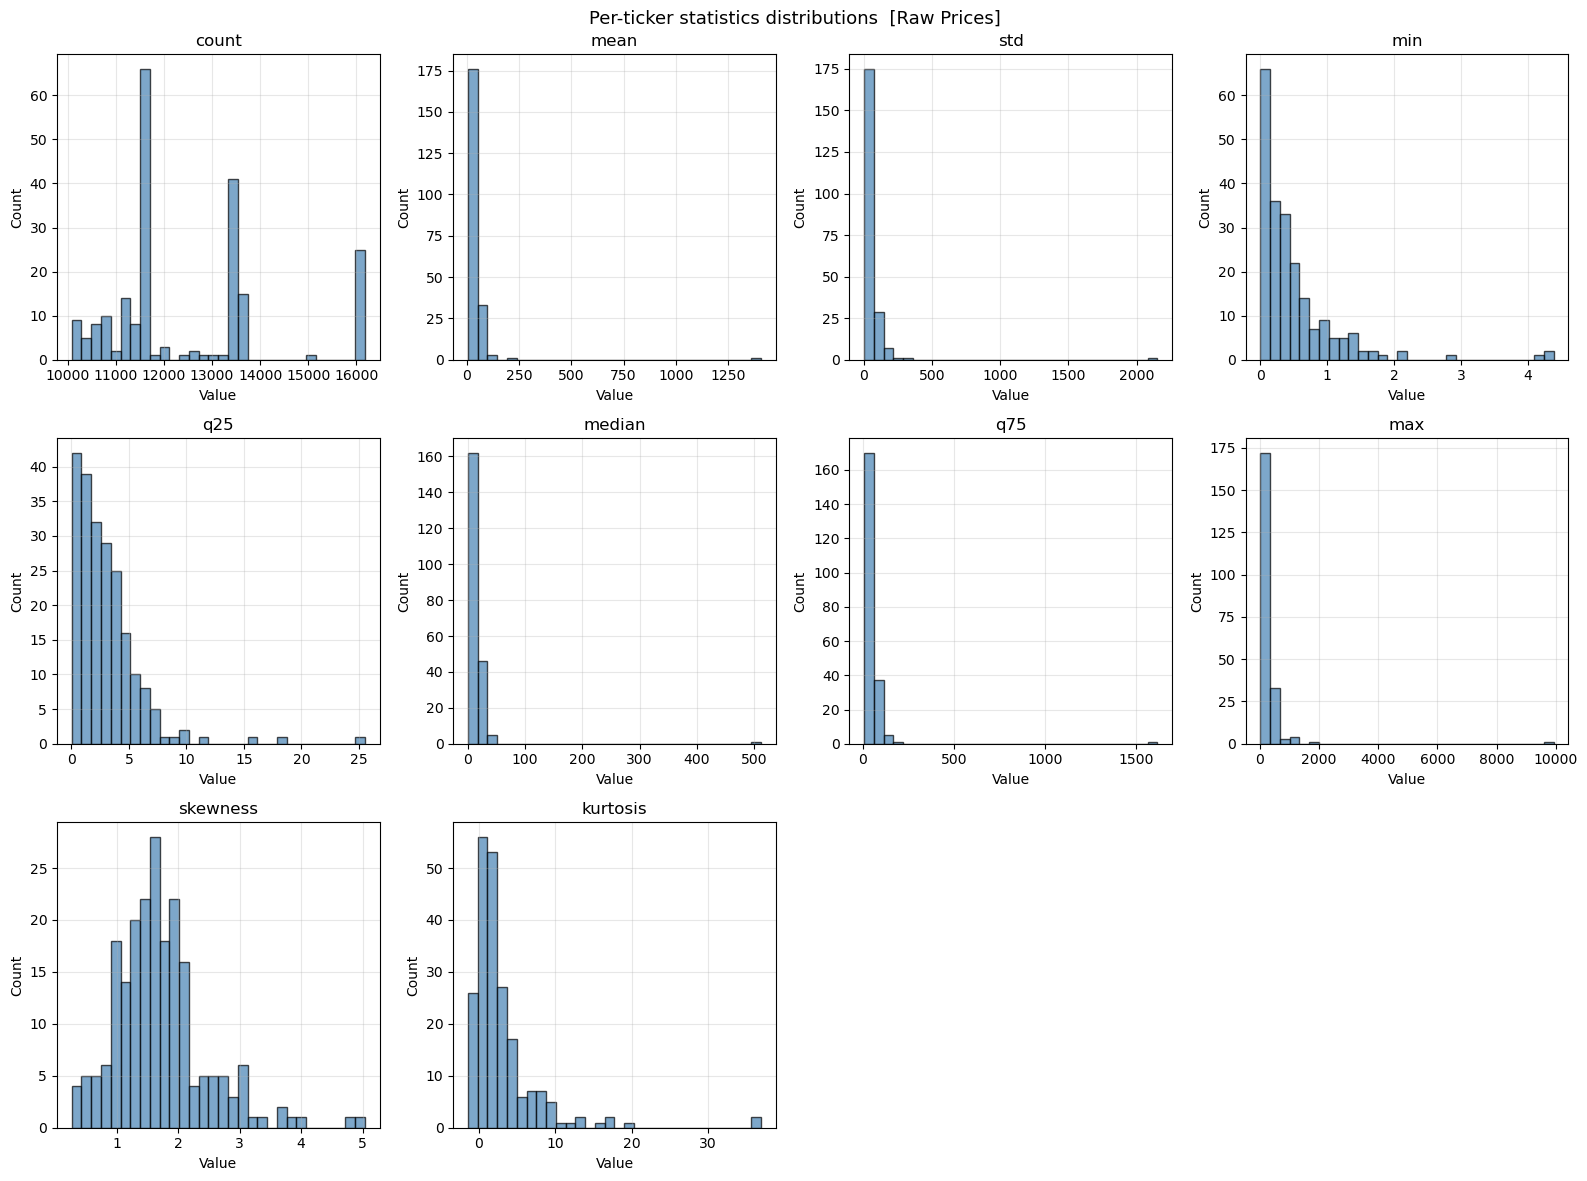

In [509]:
# 1.5  Histograms of statistics
plot_stat_histograms(raw_stats, 'Raw Prices')

In [510]:
# 1.6  Quantile filter
# ← SET quantile level here
quantile_level = 0.9

raw_outliers_any, raw_outliers_all = quantile_filter(raw_stats, quantile_level)
print("Raw outlier any:\n", raw_outliers_any)
print("Raw outlier all:\n", raw_outliers_all)


90%-quantile thresholds per statistic:
count       16176.000000
mean           66.745461
std            94.959250
min             1.172860
q25             5.818862
median         23.646292
q75            79.875102
max           469.796173
skewness        2.668297
kurtosis        7.511613

Tickers exceeding at least one 90% threshold: 75
          count       mean        std     min      q25    median        q75        max  skewness  kurtosis
ticker                                                                                                    
ADSK    10274.0    62.5802    87.0177  0.4443   6.2427   24.3700    59.1225   342.2700    1.6097    1.2682
AIG     13431.0   203.6677   294.5911  4.3740  25.5188   51.2896   200.1857  1216.8657    1.5339    0.8132
AMAT    11611.0    28.1547    52.3607  0.0553   0.3794   10.3896    19.1977   399.4900    3.0181   10.3398
AMD     11611.0    25.2605    40.6040  1.6200   5.6350   10.6400    17.9500   264.3300    2.8512    8.2260
AMGN    10788.0   

In [ ]:
print("Std outliers")
raw_outliers_any[raw_outliers_any['std'] > raw_stats['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(10)

Std outliers


Index(['NVR', 'AIG', 'GWW', 'KLAC', 'LLY', 'TMO', 'PH', 'TYL', 'NOC', 'UNH'], dtype='object', name='ticker')

In [512]:
print("Skewness outliers")
raw_outliers_any[raw_outliers_any['skewness'] > raw_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(10).index

Skewness outliers


Index(['MU', 'WDC', 'LRCX', 'KLAC', 'CAT', 'LLY', 'TPL', 'GLW', 'TER', 'WSM'], dtype='object', name='ticker')

In [513]:

print("Kurtosis outliers")
raw_outliers_any[raw_outliers_any['kurtosis'] > raw_stats['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(10).index

Kurtosis outliers


Index(['WDC', 'MU', 'LRCX', 'CAT', 'GLW', 'KLAC', 'TER', 'LLY', 'TPL', 'AMAT'], dtype='object', name='ticker')


── WDC  [adj_close] ──
count       11958.000000
mean           19.493525
std            28.446584
min             0.415382
25%             3.176546
50%             7.590177
75%            29.166262
max           343.429993
skewness        4.801470
kurtosis       36.912277


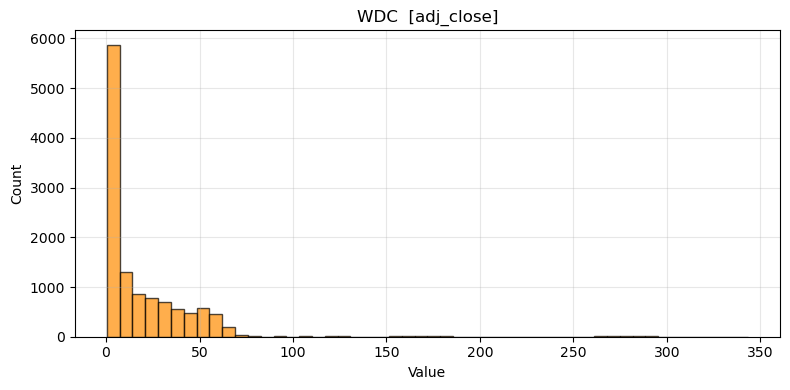


── MU  [adj_close] ──
count       10546.000000
mean           27.149489
std            43.018613
min             0.334750
25%             5.063164
50%            13.419950
75%            33.891224
max           461.536133
skewness        5.036299
kurtosis       36.207832


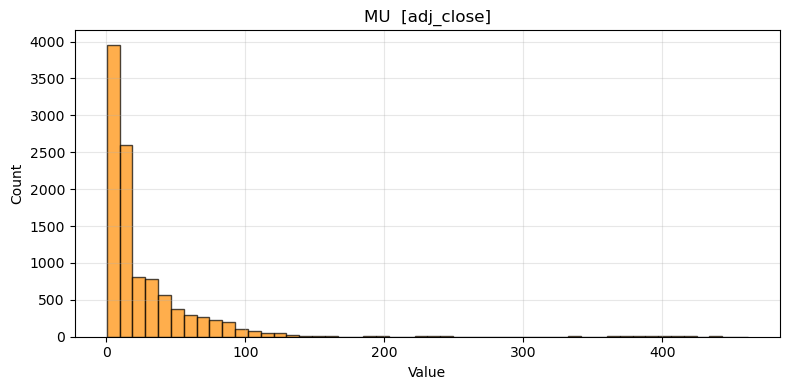


── LRCX  [adj_close] ──
count       10565.000000
mean           13.358855
std            29.557598
min             0.056600
25%             0.753481
50%             2.494339
75%             6.749015
max           263.660004
skewness        3.927891
kurtosis       19.890641


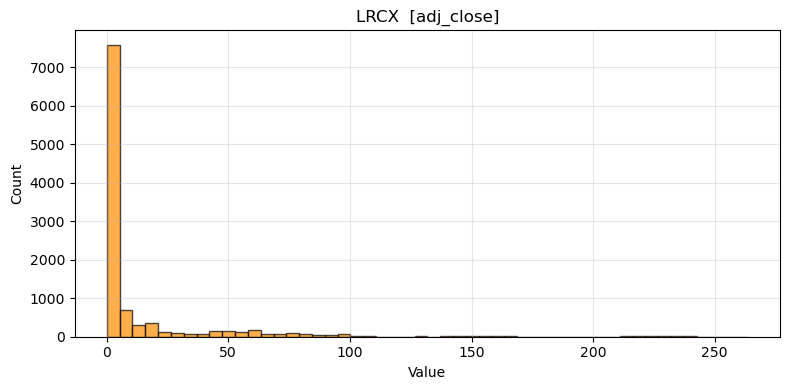


── CAT  [adj_close] ──
count       16176.000000
mean           44.443635
std            90.702907
min             0.360942
25%             2.016531
50%             5.847363
75%            48.284943
max           790.659973
skewness        3.724692
kurtosis       17.540608


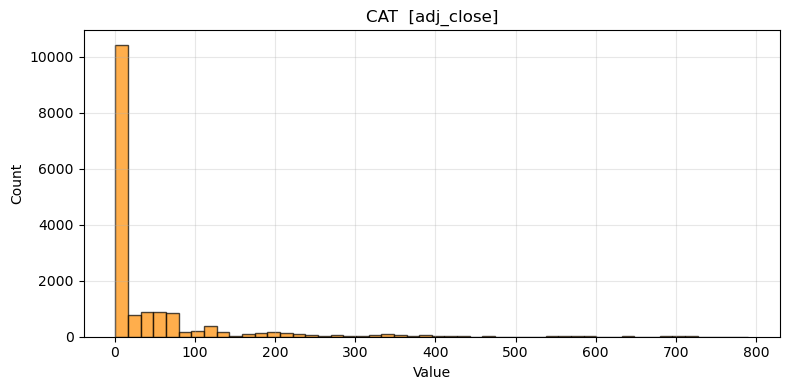


── NVR  [adj_close] ──
count       10259.000000
mean         1408.930004
std          2151.541403
min             0.250000
25%            18.676746
50%           512.000000
75%          1614.114990
max          9924.400391
skewness        1.882000
kurtosis        2.683819


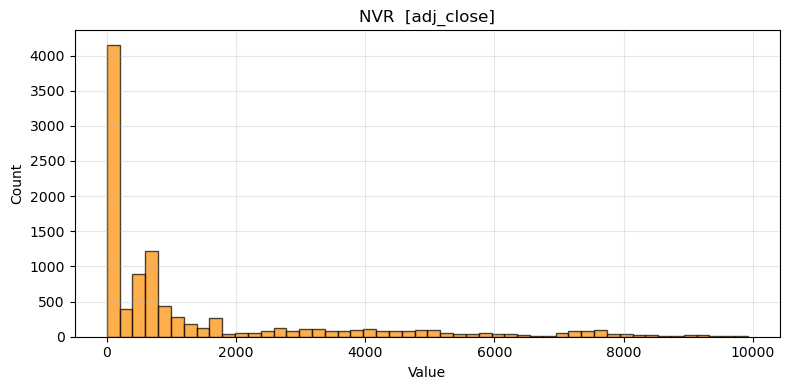


── AIG  [adj_close] ──
count       13431.000000
mean          203.667744
std           294.591087
min             4.374003
25%            25.518789
50%            51.289627
75%           200.185715
max          1216.865723
skewness        1.533876
kurtosis        0.813225


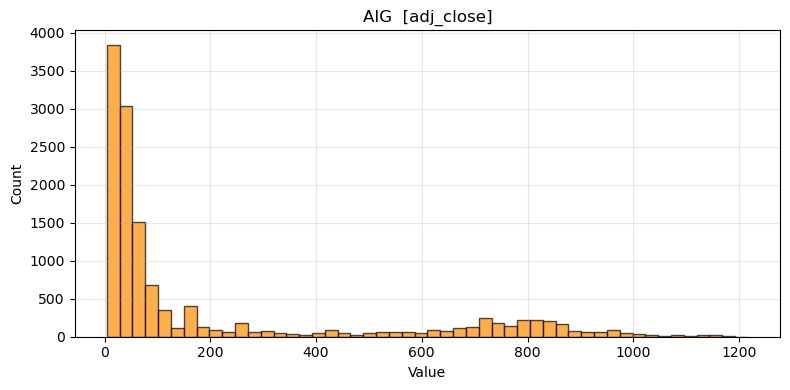


── GWW  [adj_close] ──
count       13397.000000
mean          127.048239
std           231.353635
min             1.011217
25%             5.534167
50%            28.490551
75%           162.096863
max          1207.812378
skewness        2.722498
kurtosis        7.192437


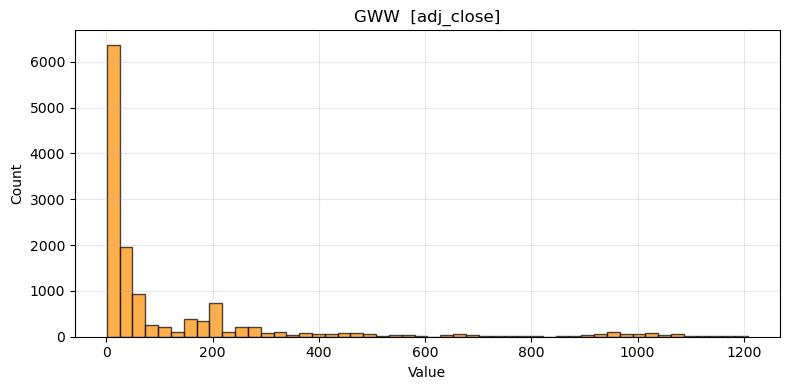

In [514]:
# 1.7  Ticker histograms
# ← SET tickers to inspect here
tickers_to_plot = ['WDC', 'MU','LRCX','CAT', 'NVR', 'AIG','GWW']

plot_ticker_histograms(raw_clean, tickers_to_plot, 'adj_close')

---
## Section 2 — Log Adjusted Close Prices

Data folder: `../data/log_replication`  |  Column: `log_adj_close`

In [515]:
# 2.1  Load
log_data = load_csvs('../data/log_replication', 'log_adj_close')

Loaded 214 tickers from: ..\data\log_replication


In [516]:
# 2.2  NaN audit + clean
log_clean = analyze_nans(log_data)

No NaN values found in any ticker.
Total NaNs across all tickers: 0


In [517]:
# 2.3  Per-ticker statistics
log_stats = compute_all_stats(log_clean)
print(f'Statistics computed for {len(log_stats)} tickers.')
log_stats.head()

Statistics computed for 214 tickers.


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
AAPL,11423.0,0.675611,2.623319,-3.280500,-1.396642,-0.699076,3.089160,5.655721,0.454638,-1.239175
ABT,11611.0,2.141234,1.766585,-1.743497,0.935495,2.452053,3.478303,4.924623,-0.358466,-0.816155
ADI,11611.0,2.493427,1.796019,-0.996792,0.698784,3.007807,3.782223,5.885198,-0.158055,-1.170428
ADM,11611.0,2.289111,1.254140,-0.419619,1.574828,2.214264,3.390977,4.477474,-0.300568,-0.889311
ADP,11611.0,2.727095,1.770268,-0.954270,1.291343,3.049454,4.038433,5.764542,-0.228917,-0.888137


In [518]:
# 2.4  Distribution of statistics
describe_stats(log_stats, 'Log Prices')


Distribution of per-ticker statistics  [Log Prices]
              count        mean         std         min         q25      median         q75         max    skewness    kurtosis
count    214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000
mean   12473.322430    2.143551    1.739052   -1.353062    0.692941    2.350063    3.564750    5.109931   -0.192195   -0.989563
std     1698.796946    0.725606    0.423360    1.285137    1.018768    0.783451    0.699808    0.906336    0.342907    0.373403
min    10084.000000   -0.671998    0.629558   -6.563852   -3.651597   -0.699076    1.883464    2.944616   -1.187219   -1.693898
25%    11469.250000    1.705475    1.459006   -2.160518    0.164126    1.980422    3.089897    4.460567   -0.423078   -1.239454
50%    11611.000000    2.194029    1.715411   -1.155240    0.881646    2.363033    3.601224    5.123071   -0.207091   -1.028914
75%    13397.000000    2.617186    1.994926   -0.50

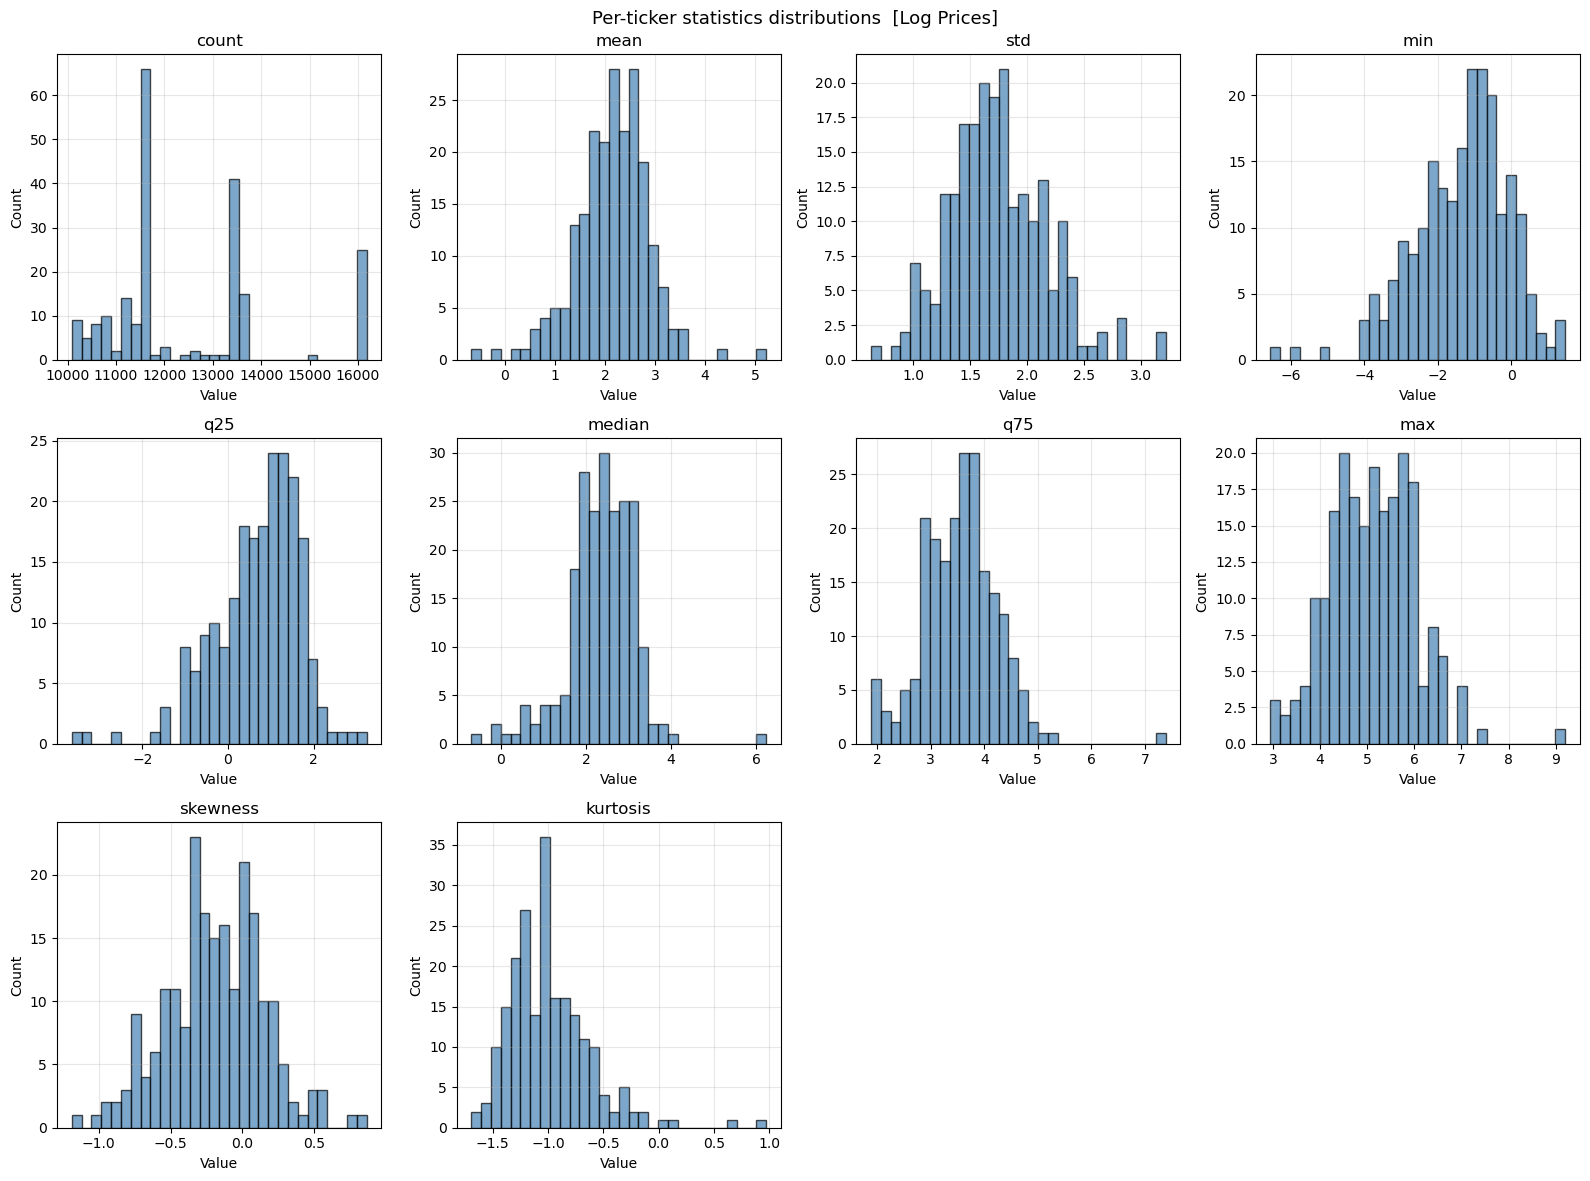

In [519]:
# 2.5  Histograms of statistics
plot_stat_histograms(log_stats, 'Log Prices')

In [520]:
# 2.6  Quantile filter
quantile_level = 0.9  # ← SET

log_outliers = quantile_filter(log_stats, quantile_level)


90%-quantile thresholds per statistic:
count       16176.000000
mean            2.904576
std             2.296606
min             0.159234
q25             1.760923
median          3.162920
q75             4.380440
max             6.152285
skewness        0.218902
kurtosis       -0.553106

Tickers exceeding at least one 90% threshold: 96
          count    mean     std     min     q25  median     q75     max  skewness  kurtosis
ticker                                                                                     
AAPL    11423.0  0.6756  2.6233 -3.2805 -1.3966 -0.6991  3.0892  5.6557    0.4546   -1.2392
ADSK    10274.0  3.0887  1.5514 -0.8112  1.8314  3.1934  4.0796  5.8356    0.0607   -0.8799
AIG     13431.0  4.2850  1.4390  1.4757  3.2394  3.9375  5.2992  7.1040    0.4546   -0.9052
AJG     10533.0  2.6227  1.5649 -0.5382  1.1860  2.7254  3.6535  5.8446    0.2420   -0.9188
AMD     11611.0  2.5009  1.0928  0.4824  1.7290  2.3646  2.8876  5.5772    0.7901    0.1700
AME     10513.0 


── WDC  [log_adj_close] ──
count       11958.000000
mean            2.191572
std             1.298144
min            -0.878556
25%             1.155791
50%             2.026855
75%             3.373013
max             5.838983
skewness        0.087380
kurtosis       -0.997259


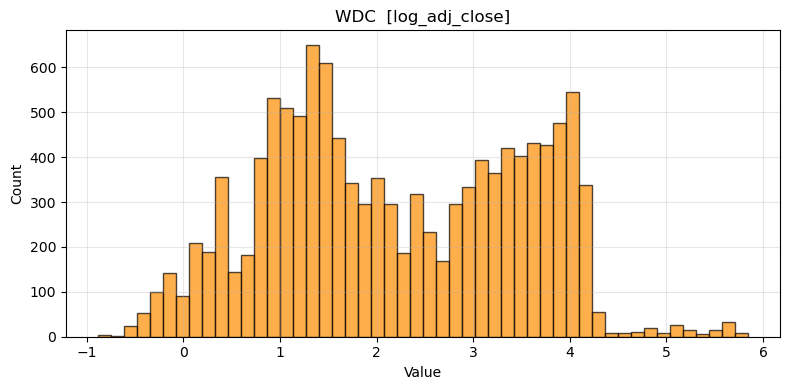


── MU  [log_adj_close] ──
count       10546.000000
mean            2.444957
std             1.435788
min            -1.094372
25%             1.621991
50%             2.596742
75%             3.523156
max             6.134560
skewness       -0.297970
kurtosis       -0.611201


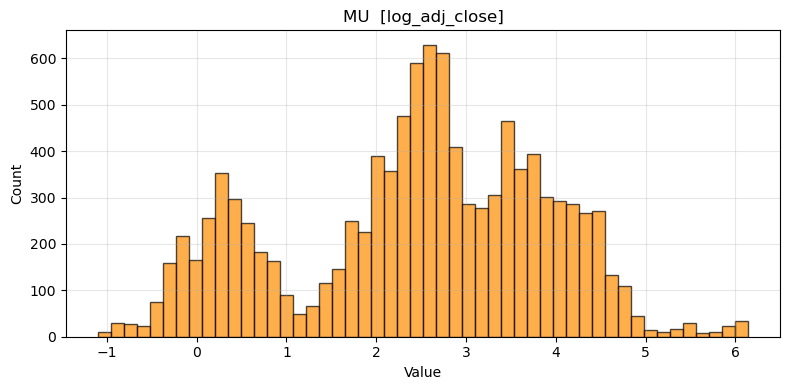


── LRCX  [log_adj_close] ──
count       10565.000000
mean            0.883712
std             1.936865
min            -2.871751
25%            -0.283052
50%             0.914024
75%             1.909397
max             5.574660
skewness        0.175888
kurtosis       -0.639000


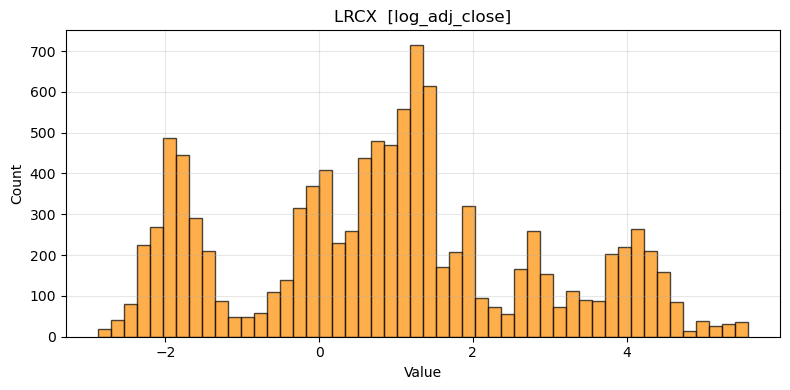


── CAT  [log_adj_close] ──
count       16176.000000
mean            2.196487
std             1.840342
min            -1.019038
25%             0.701379
50%             1.765991
75%             3.877120
max             6.672868
skewness        0.436409
kurtosis       -1.031897


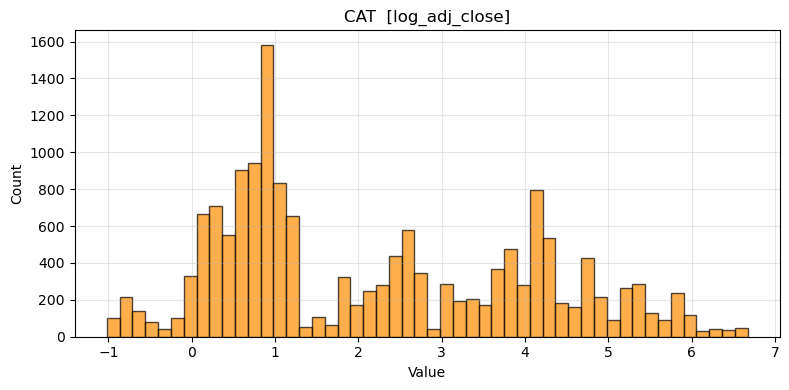


── NVR  [log_adj_close] ──
count       10259.000000
mean            5.220546
std             2.792552
min            -1.386294
25%             2.927279
50%             6.238325
75%             7.386542
max             9.202752
skewness       -0.554809
kurtosis       -0.850332


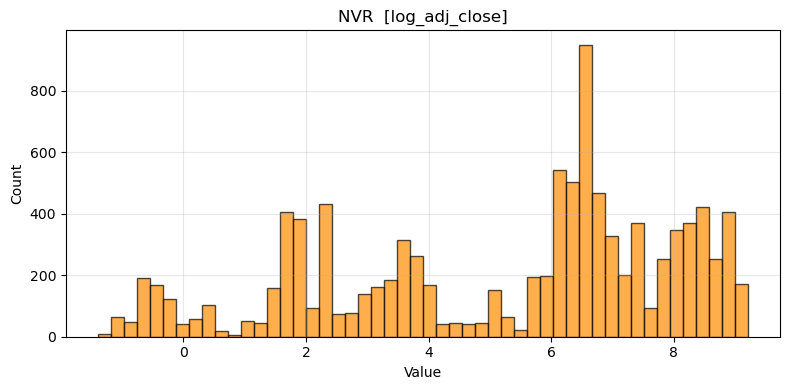


── AIG  [log_adj_close] ──
count       13431.000000
mean            4.285018
std             1.438970
min             1.475679
25%             3.239415
50%             3.937489
75%             5.299245
max             7.104034
skewness        0.454607
kurtosis       -0.905202


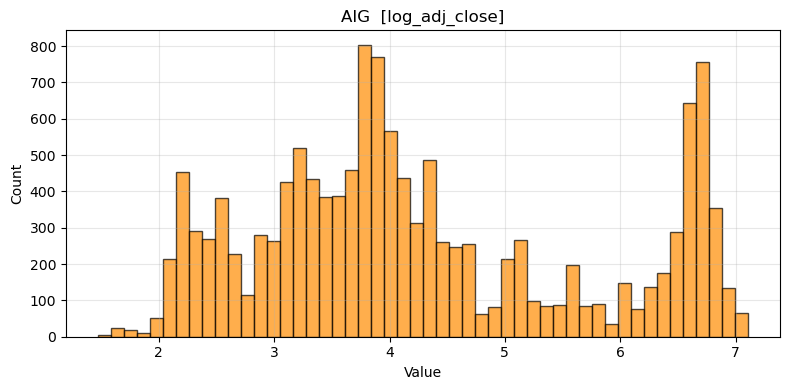


── GWW  [log_adj_close] ──
count       13397.000000
mean            3.342657
std             1.878684
min             0.011155
25%             1.710941
50%             3.349572
75%             5.088194
max             7.096566
skewness        0.133074
kurtosis       -1.043070


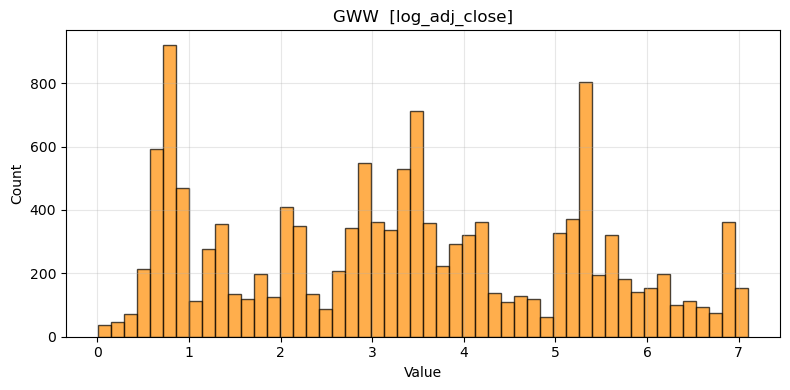

In [521]:
# 2.7  Ticker histograms
tickers_to_plot = ['WDC', 'MU','LRCX','CAT', 'NVR', 'AIG','GWW']

plot_ticker_histograms(log_clean, tickers_to_plot, 'log_adj_close')

---
## Section 3 — Increments Log-prices

First-difference of log prices: `r_t = log_adj_close_t − log_adj_close_{t−1}`.  
First row dropped per ticker.

In [522]:
# log_clean

In [523]:
# 3.1  Compute daily log-returns from cleaned log prices
increments_data = compute_increments(raw_clean)

# Because it has infinite returns
# returns_data.pop('NVR')
print("Length of returns_data:", len(increments_data))


Relative returns computed for 214 tickers (first row dropped).
Length of returns_data: 214


In [524]:
# 3.2  NaN audit (should be zero after diff + dropna)
increments_clean = analyze_nans(increments_data)

No NaN values found in any ticker.
Total NaNs across all tickers: 0


In [525]:
# 3.3  Per-ticker statistics
increments_stats = compute_all_stats(increments_clean)
print(f'Statistics computed for {len(increments_stats)} tickers.')
increments_stats.head()

Statistics computed for 214 tickers.


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
AAPL,11422.0,0.022797,1.149480,-20.610168,-0.009797,0.0,0.015943,26.315292,0.478673,61.539522
ABT,11610.0,0.008624,0.642048,-12.120003,-0.066695,0.0,0.084451,7.712952,-1.183422,44.581063
ADI,11610.0,0.030120,1.532846,-18.428833,-0.152752,0.0,0.183280,30.081070,1.012577,43.609276
ADM,11610.0,0.005930,0.469840,-15.212608,-0.080324,0.0,0.101684,3.450005,-3.786187,110.435360
ADP,11610.0,0.016228,1.246317,-20.875351,-0.100649,0.0,0.140841,17.490173,-1.530896,48.812492


In [526]:
# 3.4  Distribution of statistics
describe_stats(increments_stats, 'Daily Log-increments')


Distribution of per-ticker statistics  [Daily Log-increments]
              count        mean         std         min         q25      median         q75         max    skewness     kurtosis
count    214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   214.000000
mean   12472.322430    0.018317    1.248769  -24.071935   -0.099318    0.000032    0.128542   20.100727   -0.760842    69.839960
std     1698.796946    0.046898    3.173187   47.494365    0.206418    0.000402    0.282711   39.497191    2.229741   110.113326
min    10083.000000    0.000878    0.134478 -600.500000   -2.959995    0.000000    0.008328    1.545078  -20.149094     9.040075
25%    11468.250000    0.005369    0.431501  -24.800411   -0.116731    0.000000    0.055543    6.574421   -1.226961    31.372810
50%    11610.000000    0.009500    0.792144  -13.593843   -0.073206    0.000000    0.096416   11.269924   -0.553752    48.451796
75%    13396.000000    0.020968   

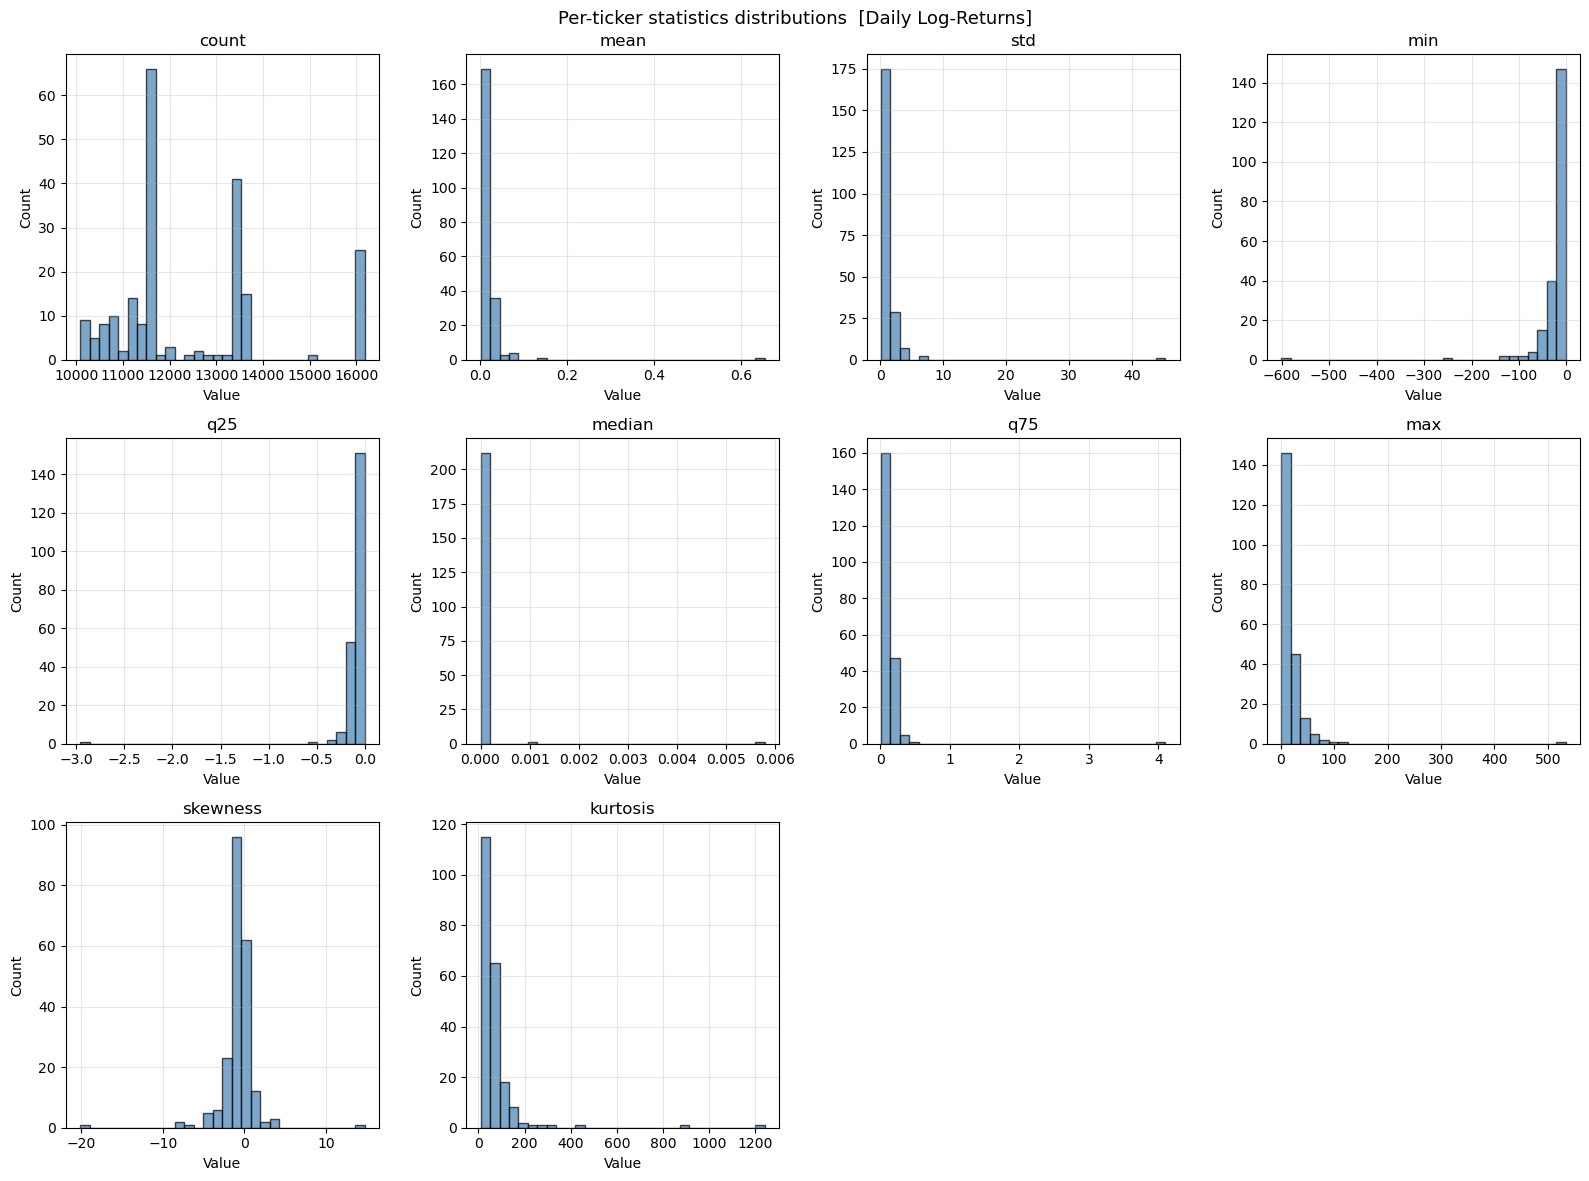

In [527]:
# 3.5  Histograms of statistics
plot_stat_histograms(increments_stats, 'Daily Log-Returns')

In [528]:
# 3.6  Quantile filter
quantile_level = 0.9  # ← SET

increments_outliers_any, increments_outliers_all = quantile_filter(increments_stats, quantile_level)


90%-quantile thresholds per statistic:
count       16175.000000
mean            0.030948
std             2.121958
min            -4.228780
q25            -0.025170
median          0.000000
q75             0.198842
max            37.104233
skewness        0.460172
kurtosis      112.049822

Tickers exceeding at least one 90% threshold: 95
          count    mean      std       min     q25  median     q75       max  skewness   kurtosis
ticker                                                                                           
AAPL    11422.0  0.0228   1.1495  -20.6102 -0.0098  0.0000  0.0159   26.3153    0.4787    61.5395
ADI     11610.0  0.0301   1.5328  -18.4288 -0.1528  0.0000  0.1833   30.0811    1.0126    43.6093
ADSK    10273.0  0.0212   2.3204  -47.1000 -0.2273  0.0000  0.2800   28.3500   -1.4176    42.8859
AIG     13430.0  0.0047   6.6955  -92.2290 -0.5033  0.0000  0.5538   67.1597   -0.5185    26.6321
AMAT    11610.0  0.0344   1.7062  -30.7900 -0.0941  0.0000  0.1136   31.

In [529]:
print("Max outliers")
print(increments_outliers_any[increments_outliers_any['max'] > increments_stats['max'].quantile(quantile_level)].sort_values('max',ascending = False).head(10).index)
increments_outliers_any[increments_outliers_any['max'] > increments_stats['max'].quantile(quantile_level)].sort_values('max',ascending = False).head(10)

Max outliers
Index(['NVR', 'KLAC', 'LLY', 'ORCL', 'GWW', 'TPL', 'PH', 'DE', 'AIG', 'CAT'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
NVR,10258.0,0.655746,45.344128,-600.500000,-2.959995,0.0,4.100006,533.319824,-0.149509,26.800203
KLAC,11467.0,0.151450,6.839436,-256.436768,-0.196947,0.0,0.263276,123.489990,-3.898077,245.590573
LLY,13576.0,0.069135,4.241305,-104.949158,-0.093482,0.0,0.133701,104.287842,-0.198524,168.630173
ORCL,10097.0,0.013671,1.591301,-24.978775,-0.111543,0.0,0.149388,86.140228,14.738006,893.599002
GWW,13396.0,0.087317,4.081495,-106.391235,-0.184046,0.0,0.235734,75.294983,-0.432027,97.732777
TPL,11610.0,0.035269,2.919753,-70.309998,-0.009155,0.0,0.012491,70.901001,-1.523838,143.273621
PH,11610.0,0.084569,3.181959,-71.617676,-0.181949,0.0,0.237648,69.973022,1.533941,100.595728
DE,13576.0,0.044516,2.461690,-48.584381,-0.092770,0.0,0.120125,68.529541,1.522838,90.462446
AIG,13430.0,0.004717,6.695503,-92.228951,-0.503279,0.0,0.553766,67.159729,-0.518482,26.632135


In [530]:
print("Min outliers")
print(increments_outliers_any[increments_outliers_any['min'] < increments_stats['min'].quantile(quantile_level)].sort_values('min',ascending = True).head(10).index)
increments_outliers_any[increments_outliers_any['min'] < increments_stats['min'].quantile(quantile_level)].sort_values('min',ascending = True).head(10)

Min outliers
Index(['NVR', 'KLAC', 'UNH', 'WST', 'GWW', 'LLY', 'AIG', 'HUM', 'PH', 'TPL'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
NVR,10258.0,0.655746,45.344128,-600.500000,-2.959995,0.0,4.100006,533.319824,-0.149509,26.800203
KLAC,11467.0,0.151450,6.839436,-256.436768,-0.196947,0.0,0.263276,123.489990,-3.898077,245.590573
UNH,10449.0,0.029115,3.319328,-127.339264,-0.150193,0.0,0.220009,32.204346,-7.441567,264.216439
WST,11610.0,0.022060,2.715117,-122.736786,-0.054365,0.0,0.071613,51.658676,-8.427168,421.572744
GWW,13396.0,0.087317,4.081495,-106.391235,-0.184046,0.0,0.235734,75.294983,-0.432027,97.732777
LLY,13576.0,0.069135,4.241305,-104.949158,-0.093482,0.0,0.133701,104.287842,-0.198524,168.630173
AIG,13430.0,0.004717,6.695503,-92.228951,-0.503279,0.0,0.553766,67.159729,-0.518482,26.632135
HUM,11157.0,0.017053,3.358261,-84.465973,-0.253200,0.0,0.327413,44.334229,-2.983679,83.572299
PH,11610.0,0.084569,3.181959,-71.617676,-0.181949,0.0,0.237648,69.973022,1.533941,100.595728


In [531]:
print("Std outliers")
print(increments_outliers_any[increments_outliers_any['std'] > increments_stats['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(10).index)
increments_outliers_any[increments_outliers_any['std'] > increments_stats['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(10)

Std outliers
Index(['NVR', 'KLAC', 'AIG', 'LLY', 'GWW', 'HUM', 'TMO', 'UNH', 'TYL', 'PH'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
NVR,10258.0,0.655746,45.344128,-600.500000,-2.959995,0.0,4.100006,533.319824,-0.149509,26.800203
KLAC,11467.0,0.151450,6.839436,-256.436768,-0.196947,0.0,0.263276,123.489990,-3.898077,245.590573
AIG,13430.0,0.004717,6.695503,-92.228951,-0.503279,0.0,0.553766,67.159729,-0.518482,26.632135
LLY,13576.0,0.069135,4.241305,-104.949158,-0.093482,0.0,0.133701,104.287842,-0.198524,168.630173
GWW,13396.0,0.087317,4.081495,-106.391235,-0.184046,0.0,0.235734,75.294983,-0.432027,97.732777
HUM,11157.0,0.017053,3.358261,-84.465973,-0.253200,0.0,0.327413,44.334229,-2.983679,83.572299
TMO,11610.0,0.042587,3.329461,-42.052063,-0.210459,0.0,0.271259,45.630554,0.417002,31.160170
UNH,10449.0,0.029115,3.319328,-127.339264,-0.150193,0.0,0.220009,32.204346,-7.441567,264.216439
TYL,11610.0,0.027256,3.229874,-59.640015,-0.125000,0.0,0.125000,48.540039,-0.605695,50.747855


In [532]:
print("Skewness outliers")
print(increments_outliers_any[increments_outliers_any['skewness'] > increments_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(10).index)
increments_outliers_any[increments_outliers_any['skewness'] > increments_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(10)

Skewness outliers
Index(['ORCL', 'CAT', 'CAH', 'CASY', 'WDC', 'WSM', 'PH', 'DE', 'GLW', 'TER'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
ORCL,10097.0,0.013671,1.591301,-24.978775,-0.111543,0.0,0.149388,86.140228,14.738006,893.599002
CAT,16175.0,0.048853,2.019812,-30.140015,-0.047294,0.0,0.059594,60.877563,4.063308,154.470663
CAH,10754.0,0.019985,0.781542,-11.267548,-0.133388,0.0,0.184202,25.245712,3.517908,168.845072
CASY,10700.0,0.068900,2.194170,-33.209869,-0.149473,0.0,0.193079,54.167267,3.214166,98.520706
WDC,11957.0,0.028665,1.337481,-28.166534,-0.132921,0.0,0.151049,31.484924,3.004412,186.875228
WSM,10774.0,0.017524,1.188213,-25.751205,-0.085546,0.0,0.099027,37.117004,2.396307,150.131795
PH,11610.0,0.084569,3.181959,-71.617676,-0.181949,0.0,0.237648,69.973022,1.533941,100.595728
DE,13576.0,0.044516,2.461690,-48.584381,-0.092770,0.0,0.120125,68.529541,1.522838,90.462446
GLW,11157.0,0.015279,0.706124,-11.450005,-0.084091,0.0,0.103100,16.580002,1.488858,112.741733


In [533]:

print("Kurtosis outliers")
print(increments_outliers_any[increments_outliers_any['kurtosis'] > increments_stats['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(10).index)
increments_outliers_any[increments_outliers_any['kurtosis'] > increments_stats['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(10)

Kurtosis outliers
Index(['GL', 'ORCL', 'WST', 'TGT', 'UNH', 'KLAC', 'WDC', 'ETN', 'CAH', 'LLY'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
GL,11472.0,0.012595,0.894519,-54.771721,-0.083535,0.0,0.117501,9.744183,-20.149094,1241.553390
ORCL,10097.0,0.013671,1.591301,-24.978775,-0.111543,0.0,0.149388,86.140228,14.738006,893.599002
WST,11610.0,0.022060,2.715117,-122.736786,-0.054365,0.0,0.071613,51.658676,-8.427168,421.572744
TGT,13396.0,0.009086,1.146826,-47.275269,-0.066530,0.0,0.087001,18.111870,-6.199484,297.859090
UNH,10449.0,0.029115,3.319328,-127.339264,-0.150193,0.0,0.220009,32.204346,-7.441567,264.216439
KLAC,11467.0,0.151450,6.839436,-256.436768,-0.196947,0.0,0.263276,123.489990,-3.898077,245.590573
WDC,11957.0,0.028665,1.337481,-28.166534,-0.132921,0.0,0.151049,31.484924,3.004412,186.875228
ETN,13576.0,0.029659,1.588045,-56.679565,-0.045038,0.0,0.064472,31.786682,-3.471843,180.635676
CAH,10754.0,0.019985,0.781542,-11.267548,-0.133388,0.0,0.184202,25.245712,3.517908,168.845072



── NVR  [Daily Log-Increments] ──
count       10258.000000
mean            0.655746
std            45.344128
min          -600.500000
25%            -2.959995
50%             0.000000
75%             4.100006
max           533.319824
skewness       -0.149509
kurtosis       26.800203


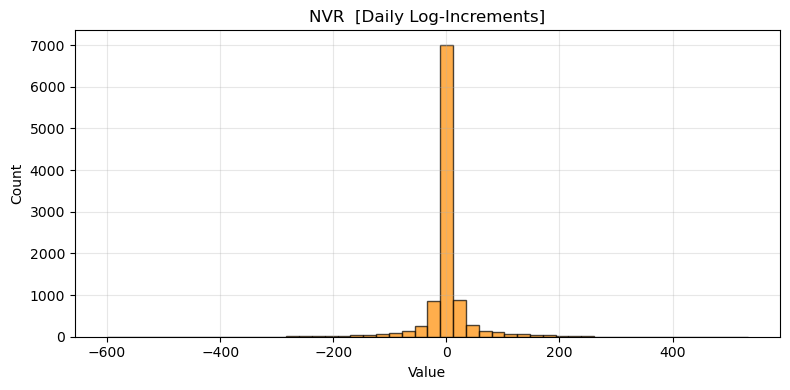


── KLAC  [Daily Log-Increments] ──
count       11467.000000
mean            0.151450
std             6.839436
min          -256.436768
25%            -0.196947
50%             0.000000
75%             0.263276
max           123.489990
skewness       -3.898077
kurtosis      245.590573


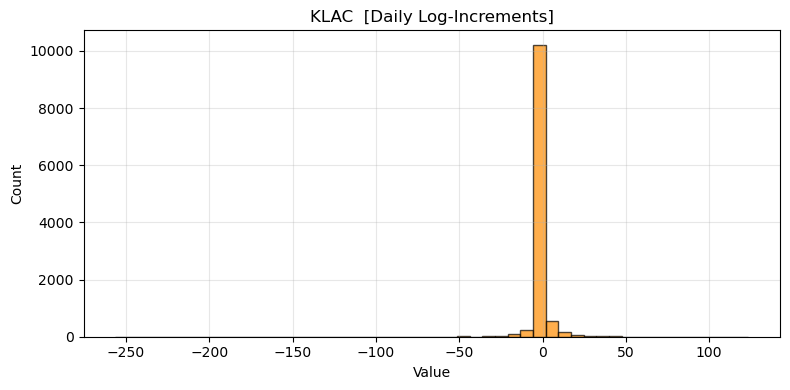


── LLY  [Daily Log-Increments] ──
count       13576.000000
mean            0.069135
std             4.241305
min          -104.949158
25%            -0.093482
50%             0.000000
75%             0.133701
max           104.287842
skewness       -0.198524
kurtosis      168.630173


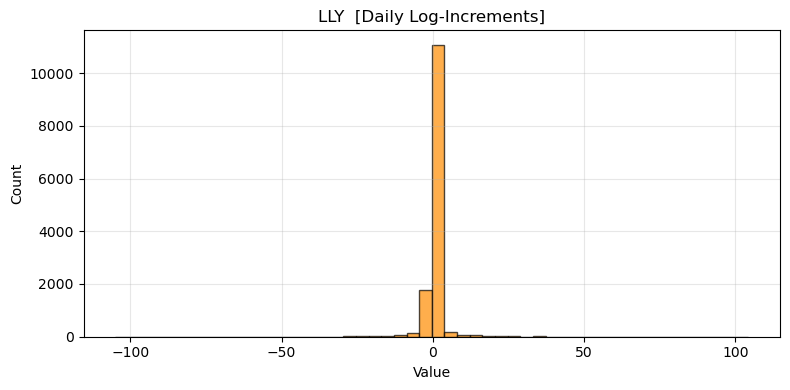


── AIG  [Daily Log-Increments] ──
count       13430.000000
mean            0.004717
std             6.695503
min           -92.228951
25%            -0.503279
50%             0.000000
75%             0.553766
max            67.159729
skewness       -0.518482
kurtosis       26.632135


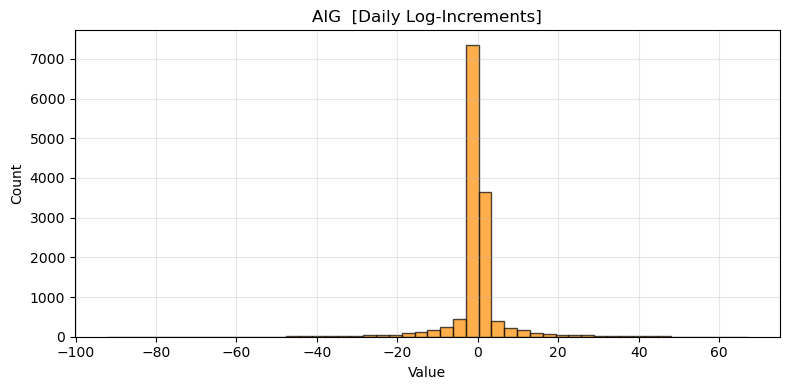


── UNH  [Daily Log-Increments] ──
count       10449.000000
mean            0.029115
std             3.319328
min          -127.339264
25%            -0.150193
50%             0.000000
75%             0.220009
max            32.204346
skewness       -7.441567
kurtosis      264.216439


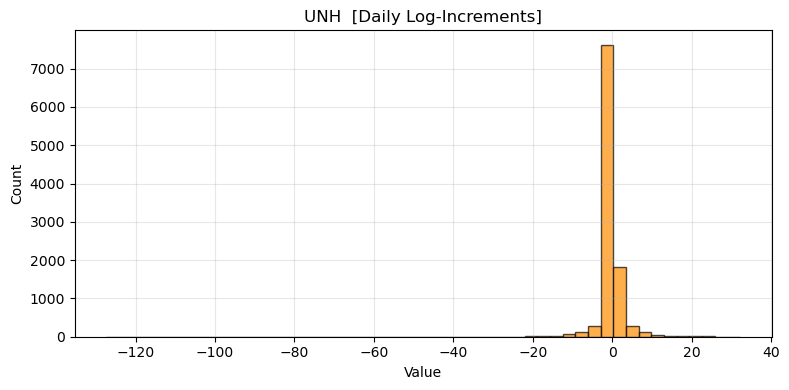

In [574]:
# 3.7  Ticker histograms
tickers_to_plot = ['NVR', 'KLAC', 'LLY','AIG','UNH']  # ← SET

plot_ticker_histograms(increments_clean, tickers_to_plot, 'Daily Log-Increments')

In [535]:
ticker = 'NVR'
s = raw_clean[ticker]

max_val = s.max()
print(s[s == max_val])

start_date = '1993-09-25'
end_date = '1993-10-7'

print("Returns", s[(s.index < end_date) & (s.index > start_date)], "\n")

date
2024-10-18    9924.400391
Name: adj_close, dtype: float64
Returns date
1993-09-27     0.375
1993-09-28     0.375
1993-09-29     0.375
1993-09-30     0.375
1993-10-01    10.250
1993-10-04    10.000
1993-10-05    10.125
1993-10-06    10.250
Name: adj_close, dtype: float64 



---
## Section 4 — Daily Log-Returns

First-difference of log prices: `r_t = log_adj_close_t − log_adj_close_{t−1}`.  
First row dropped per ticker.

In [536]:
# log_clean

In [537]:
# 3.1  Compute daily log-returns from cleaned log prices
returns_data = compute_returns(raw_clean)

# Because it has infinite returns
# returns_data.pop('NVR')
print("Length of returns_data:", len(returns_data))


Log-returns computed for 214 tickers (first row dropped).
Length of returns_data: 214


In [538]:
# 3.2  NaN audit (should be zero after diff + dropna)
returns_clean = analyze_nans(returns_data)

No NaN values found in any ticker.
Total NaNs across all tickers: 0


In [539]:
# 3.3  Per-ticker statistics
returns_stats = compute_all_stats(returns_clean)
print(f'Statistics computed for {len(returns_stats)} tickers.')
returns_stats.head()

Statistics computed for 214 tickers.


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
AAPL,11422.0,0.000690,0.027991,-0.731247,-0.012486,0.0,0.014042,0.286892,-1.731976,48.170627
ABT,11610.0,0.000545,0.015997,-0.175992,-0.008004,0.0,0.009077,0.117484,-0.269159,5.618790
ADI,11610.0,0.000574,0.027201,-0.214776,-0.012815,0.0,0.013333,0.189905,0.076587,5.223629
ADM,11610.0,0.000377,0.019536,-0.277034,-0.009353,0.0,0.010554,0.159887,-0.489668,10.784514
ADP,11610.0,0.000533,0.016429,-0.278922,-0.007326,0.0,0.008658,0.164068,-0.798189,18.852504


In [540]:
# 3.4  Distribution of statistics
describe_stats(returns_stats, 'Daily Log-Returns')


Distribution of per-ticker statistics  [Daily Log-Returns]
              count        mean         std         min         q25      median         q75         max    skewness     kurtosis
count    214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   214.000000
mean   12472.322430    0.000460    0.020710   -0.320949   -0.009040    0.000004    0.009931    0.254179   -0.161779    66.061340
std     1698.796946    0.000132    0.005811    0.184631    0.002515    0.000036    0.002422    0.277431    4.881536   430.675809
min    10083.000000    0.000129    0.012167   -1.525526   -0.019802    0.000000    0.002909    0.102049  -10.238005     3.741907
25%    11468.250000    0.000384    0.017020   -0.359621   -0.010000    0.000000    0.008237    0.164543   -0.585283     8.518035
50%    11610.000000    0.000460    0.019550   -0.267534   -0.008582    0.000000    0.009534    0.200034   -0.268473    13.324422
75%    13396.000000    0.000533    0.

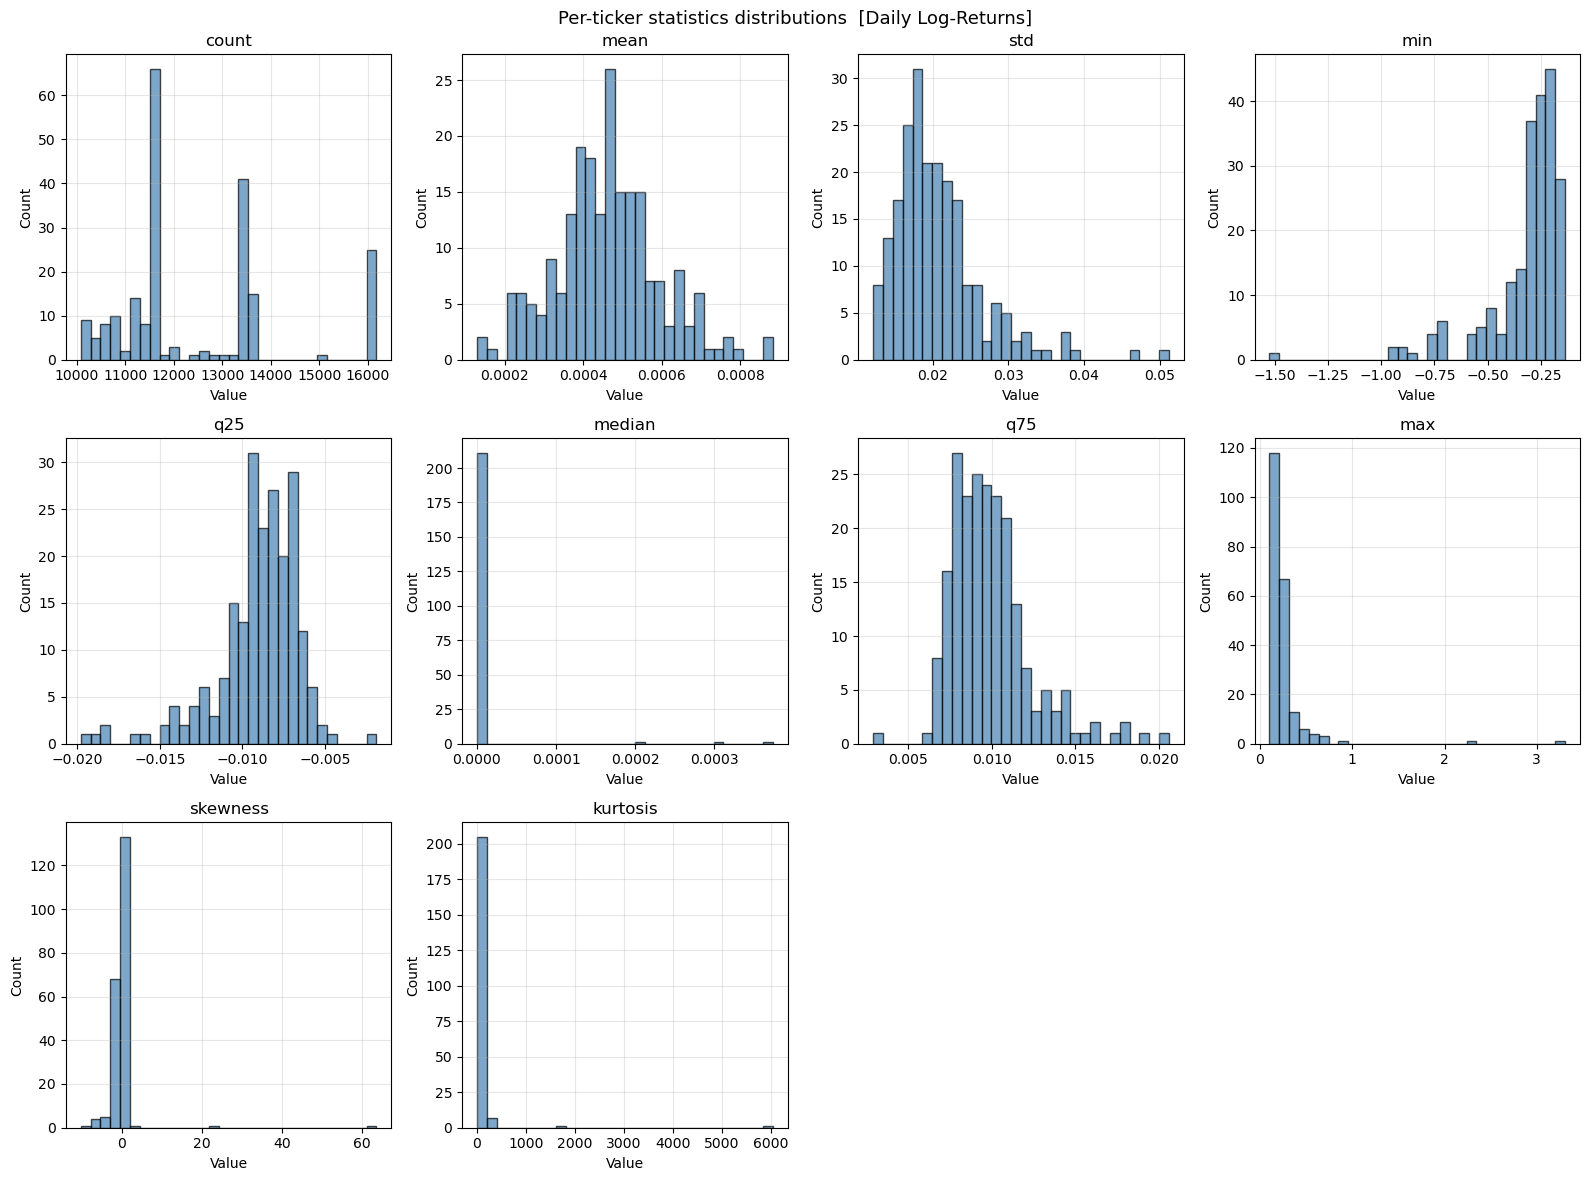

In [541]:
# 3.5  Histograms of statistics
plot_stat_histograms(returns_stats, 'Daily Log-Returns')

In [542]:
# 3.6  Quantile filter
quantile_level = 0.9  # ← SET

returns_outliers_any, returns_outliers_all = quantile_filter(returns_stats, quantile_level)


90%-quantile thresholds per statistic:
count       16175.000000
mean            0.000633
std             0.027925
min            -0.175921
q25            -0.006674
median          0.000000
q75             0.013031
max             0.377219
skewness        0.153081
kurtosis       59.690458

Tickers exceeding at least one 90% threshold: 108
          count    mean     std     min     q25  median     q75     max  skewness   kurtosis
ticker                                                                                      
AAPL    11422.0  0.0007  0.0280 -0.7312 -0.0125  0.0000  0.0140  0.2869   -1.7320    48.1706
ADI     11610.0  0.0006  0.0272 -0.2148 -0.0128  0.0000  0.0133  0.1899    0.0766     5.2236
ADSK    10273.0  0.0006  0.0285 -0.2561 -0.0133  0.0000  0.0144  0.3392   -0.2874     8.4536
AEP     16175.0  0.0003  0.0131 -0.2586 -0.0062  0.0000  0.0069  0.1810   -0.2356    19.9005
AFL     11610.0  0.0007  0.0225 -0.4599 -0.0088  0.0000  0.0097  0.3580   -0.7789    39.2597
AIG     

In [543]:
print("Max outliers")
print(returns_outliers_any[returns_outliers_any['max'] > returns_stats['max'].quantile(quantile_level)].sort_values('max',ascending = False).head(10).index)
returns_outliers_any[returns_outliers_any['max'] > returns_stats['max'].quantile(quantile_level)].sort_values('max',ascending = False).head(10)

Max outliers
Index(['NVR', 'HUBB', 'BEN', 'WMB', 'MNST', 'PNW', 'DVN', 'PCG', 'COO',
       'JKHY'],
      dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
NVR,10258.0,0.000552,0.051209,-1.525526,-0.010602,0.0,0.011647,3.308107,23.730531,1777.434692
HUBB,13453.0,0.000588,0.024093,-0.154885,-0.001881,0.0,0.002909,2.288416,63.635014,6043.346222
BEN,10719.0,0.000638,0.026457,-0.911152,-0.010548,0.0,0.011708,0.921412,0.043636,274.118976
WMB,11157.0,0.000426,0.029194,-0.942802,-0.010329,0.0,0.011535,0.698185,-2.784164,154.857654
MNST,10161.0,0.000692,0.046276,-0.693147,-0.009528,0.0,0.010391,0.693147,0.607248,49.528176
PNW,13396.0,0.000239,0.016034,-0.264692,-0.006825,0.0,0.007490,0.645519,4.405478,216.134769
DVN,10258.0,0.000263,0.027935,-0.468359,-0.013086,0.0,0.013884,0.627189,0.655902,39.147261
PCG,13576.0,0.000223,0.022503,-0.741483,-0.006785,0.0,0.007782,0.557289,-4.004437,187.393025
COO,10889.0,0.000211,0.033383,-0.405465,-0.011106,0.0,0.010965,0.538994,0.686966,25.480686


In [544]:
print("Min outliers")
print(returns_outliers_any[returns_outliers_any['min'] < returns_stats['min'].quantile(quantile_level)].sort_values('min',ascending = True).head(10).index)
returns_outliers_any[returns_outliers_any['min'] < returns_stats['min'].quantile(quantile_level)].sort_values('min',ascending = True).head(10)

Min outliers
Index(['NVR', 'WMB', 'AIG', 'BEN', 'STT', 'TSN', 'VTRS', 'APA', 'GL', 'PCG'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
NVR,10258.0,0.000552,0.051209,-1.525526,-0.010602,0.0,0.011647,3.308107,23.730531,1777.434692
WMB,11157.0,0.000426,0.029194,-0.942802,-0.010329,0.0,0.011535,0.698185,-2.784164,154.857654
AIG,13430.0,0.000129,0.027112,-0.936258,-0.008509,0.0,0.009476,0.506818,-3.509373,168.169536
BEN,10719.0,0.000638,0.026457,-0.911152,-0.010548,0.0,0.011708,0.921412,0.043636,274.118976
STT,11610.0,0.000627,0.023403,-0.892505,-0.008263,0.0,0.010050,0.272661,-4.642413,195.574711
TSN,11610.0,0.000341,0.024530,-0.843430,-0.009370,0.0,0.010527,0.204593,-7.027838,215.613467
VTRS,11610.0,0.000224,0.029764,-0.780158,-0.012578,0.0,0.012739,0.201142,-4.743497,110.914007
APA,11822.0,0.000262,0.028010,-0.773592,-0.013935,0.0,0.014311,0.258251,-1.879712,57.768018
GL,11472.0,0.000408,0.021365,-0.758010,-0.007220,0.0,0.008510,0.183778,-10.238005,353.156689


In [545]:
print("Std outliers")
print(returns_outliers_any[returns_outliers_any['std'] > returns_stats['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(10).index)
returns_outliers_any[returns_outliers_any['std'] > returns_stats['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(10)

Std outliers
Index(['NVR', 'MNST', 'SWKS', 'MU', 'WDC', 'AMD', 'LRCX', 'COO', 'TER',
       'KLAC'],
      dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
NVR,10258.0,0.000552,0.051209,-1.525526,-0.010602,0.0,0.011647,3.308107,23.730531,1777.434692
MNST,10161.0,0.000692,0.046276,-0.693147,-0.009528,0.0,0.010391,0.693147,0.607248,49.528176
SWKS,10477.0,0.000236,0.039122,-0.287682,-0.018637,0.0,0.017682,0.462624,0.455477,8.154327
MU,10545.0,0.000544,0.038035,-0.290923,-0.019802,0.0,0.020587,0.212922,-0.191625,3.859221
WDC,11957.0,0.000521,0.037635,-0.386773,-0.018350,0.0,0.018206,0.334750,0.097804,7.739927
AMD,11610.0,0.000375,0.037314,-0.476924,-0.018545,0.0,0.019379,0.420617,-0.385009,10.786687
LRCX,10564.0,0.000686,0.034874,-0.271935,-0.016262,0.0,0.017609,0.323795,0.082310,5.356807
COO,10889.0,0.000211,0.033383,-0.405465,-0.011106,0.0,0.010965,0.538994,0.686966,25.480686
TER,13396.0,0.000433,0.032014,-0.320270,-0.016104,0.0,0.016316,0.186334,-0.170964,5.424985


In [546]:
print("Skewness outliers")
print(returns_outliers_any[returns_outliers_any['skewness'] > returns_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(10).index)
returns_outliers_any[returns_outliers_any['skewness'] > returns_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(10)

Skewness outliers
Index(['HUBB', 'NVR', 'PNW', 'D', 'DHR', 'COO', 'DVN', 'MNST', 'JKHY', 'SWKS'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
HUBB,13453.0,0.000588,0.024093,-0.154885,-0.001881,0.0,0.002909,2.288416,63.635014,6043.346222
NVR,10258.0,0.000552,0.051209,-1.525526,-0.010602,0.0,0.011647,3.308107,23.730531,1777.434692
PNW,13396.0,0.000239,0.016034,-0.264692,-0.006825,0.0,0.007490,0.645519,4.405478,216.134769
D,11610.0,0.000443,0.013272,-0.160343,-0.005736,0.0,0.007053,0.382992,1.512722,71.053941
DHR,11916.0,0.000702,0.021980,-0.291054,-0.008734,0.0,0.009583,0.477590,1.014817,26.862981
COO,10889.0,0.000211,0.033383,-0.405465,-0.011106,0.0,0.010965,0.538994,0.686966,25.480686
DVN,10258.0,0.000263,0.027935,-0.468359,-0.013086,0.0,0.013884,0.627189,0.655902,39.147261
MNST,10161.0,0.000692,0.046276,-0.693147,-0.009528,0.0,0.010391,0.693147,0.607248,49.528176
JKHY,10173.0,0.000633,0.029772,-0.311859,-0.009054,0.0,0.010582,0.534079,0.459730,23.754342


In [547]:

print("Kurtosis outliers")
print(returns_outliers_any[returns_outliers_any['kurtosis'] > returns_stats['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(10).index)
returns_outliers_any[returns_outliers_any['kurtosis'] > returns_stats['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(10)

Kurtosis outliers
Index(['HUBB', 'NVR', 'GL', 'BEN', 'MRSH', 'MCD', 'TRV', 'PNW', 'TSN', 'STT'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
HUBB,13453.0,0.000588,0.024093,-0.154885,-0.001881,0.0,0.002909,2.288416,63.635014,6043.346222
NVR,10258.0,0.000552,0.051209,-1.525526,-0.010602,0.0,0.011647,3.308107,23.730531,1777.434692
GL,11472.0,0.000408,0.021365,-0.758010,-0.007220,0.0,0.008510,0.183778,-10.238005,353.156689
BEN,10719.0,0.000638,0.026457,-0.911152,-0.010548,0.0,0.011708,0.921412,0.043636,274.118976
MRSH,13396.0,0.000391,0.016900,-0.725937,-0.006973,0.0,0.007815,0.134800,-6.349732,265.751315
MCD,15040.0,0.000526,0.019043,-0.707640,-0.008109,0.0,0.008889,0.166577,-6.768575,250.572891
TRV,12703.0,0.000363,0.017762,-0.735587,-0.007131,0.0,0.007869,0.227578,-5.803483,243.524228
PNW,13396.0,0.000239,0.016034,-0.264692,-0.006825,0.0,0.007490,0.645519,4.405478,216.134769
TSN,11610.0,0.000341,0.024530,-0.843430,-0.009370,0.0,0.010527,0.204593,-7.027838,215.613467



── NVR  [Daily Log-Returns] ──
count       10258.000000
mean            0.000552
std             0.051209
min            -1.525526
25%            -0.010602
50%             0.000000
75%             0.011647
max             3.308107
skewness       23.730531
kurtosis     1777.434692


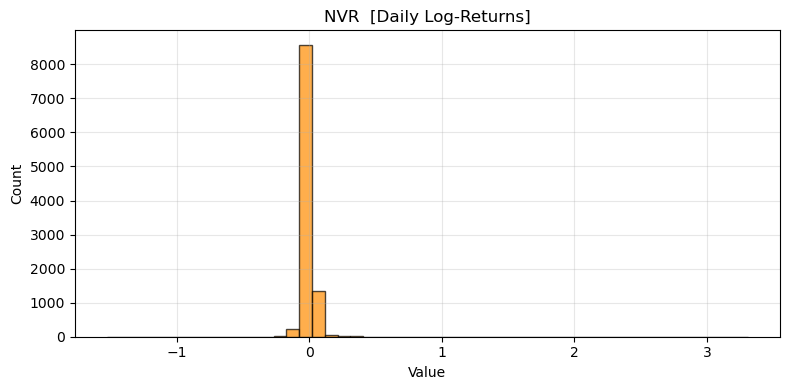


── KLAC  [Daily Log-Returns] ──
count       11467.000000
mean            0.000694
std             0.031934
min            -0.186175
25%            -0.014599
50%             0.000000
75%             0.015616
max             0.223876
skewness        0.107102
kurtosis        3.741907


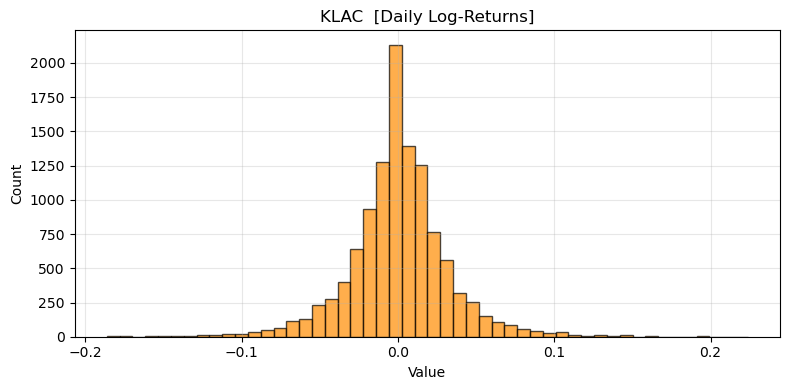


── LLY  [Daily Log-Returns] ──
count       13576.000000
mean            0.000512
std             0.017415
min            -0.345001
25%            -0.008372
50%             0.000000
75%             0.009324
max             0.153050
skewness       -0.751715
kurtosis       21.571247


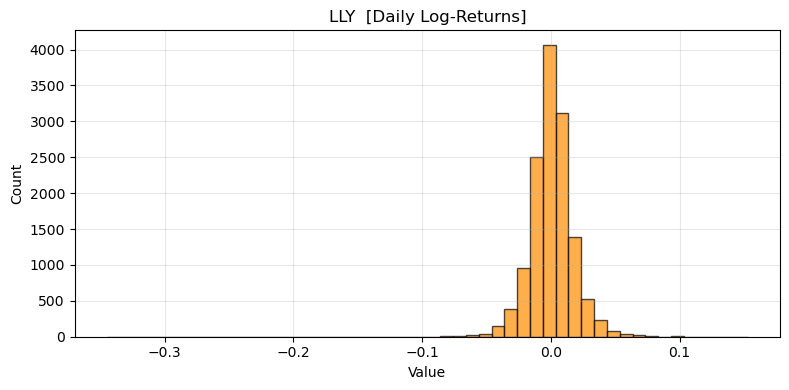

In [548]:
# 3.7  Ticker histograms
tickers_to_plot = ['NVR', 'KLAC', 'LLY']  # ← SET

plot_ticker_histograms(returns_clean, tickers_to_plot, 'Daily Log-Returns')

In [549]:
ticker = 'NVR'
s = returns_clean[ticker]

max_val = s.max()
print(s[s == max_val])

start_date = '2025-07-15'
end_date = '2025-07-28'

print("Returns", s[(s.index < end_date) & (s.index > start_date)], "\n")

date
1993-10-01    3.308107
Name: adj_close, dtype: float64
Returns date
2025-07-16    0.010232
2025-07-17    0.008392
2025-07-18   -0.002075
2025-07-21   -0.006302
2025-07-22    0.069808
2025-07-23   -0.001225
2025-07-24   -0.014080
2025-07-25    0.000454
Name: adj_close, dtype: float64 



In [550]:
s = raw_clean[ticker]
print("Raw prices", s[(s.index < end_date) & (s.index > start_date)], "\n")

Raw prices date
2025-07-16    7376.089844
2025-07-17    7438.250000
2025-07-18    7422.830078
2025-07-21    7376.200195
2025-07-22    7909.520020
2025-07-23    7899.839844
2025-07-24    7789.390137
2025-07-25    7792.930176
Name: adj_close, dtype: float64 



In [551]:
s = log_clean[ticker]
print("Log prices", s[(s.index < end_date) & (s.index > start_date)], "\n")

Log prices date
2025-07-16    8.905999
2025-07-17    8.914391
2025-07-18    8.912316
2025-07-21    8.906014
2025-07-22    8.975822
2025-07-23    8.974598
2025-07-24    8.960518
2025-07-25    8.960972
Name: log_adj_close, dtype: float64 




Aggregate statistics  [Daily Log-Returns]  (N=2,669,077)
  count       : 2,669,077
  mean        : 0.000453121
  std         : 0.0211507
  min         : -1.52553
  q25         : -0.00861972
  median      : 0
  q75         : 0.00947969
  max         : 3.30811
  skewness    : 1.19379
  kurtosis    : 327.198


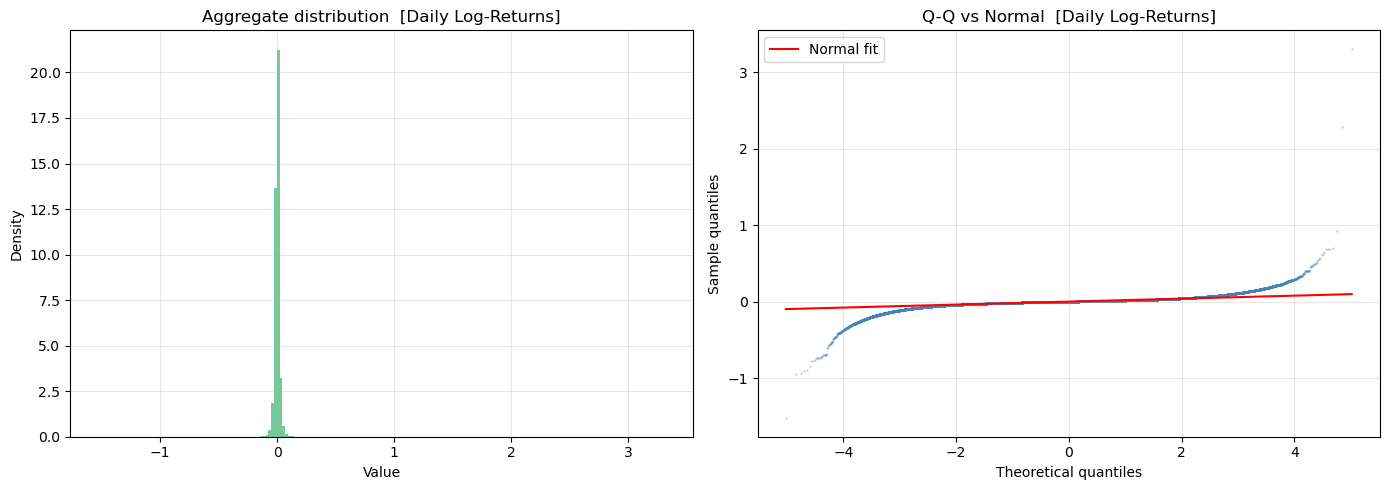

In [552]:
# 3.8  Aggregate statistics + distribution across ALL tickers combined
returns_agg = compute_aggregate_stats_and_plot(returns_clean, 'Daily Log-Returns')


Aggregate statistics  [Daily Log-Returns limited to X Standard Deviations]  (N=2,669,077)
  count       : 2,669,077
  mean        : 0.000453121
  std         : 0.0211507
  min         : -1.52553
  q25         : -0.00861972
  median      : 0
  q75         : 0.00947969
  max         : 3.30811
  skewness    : 327.198


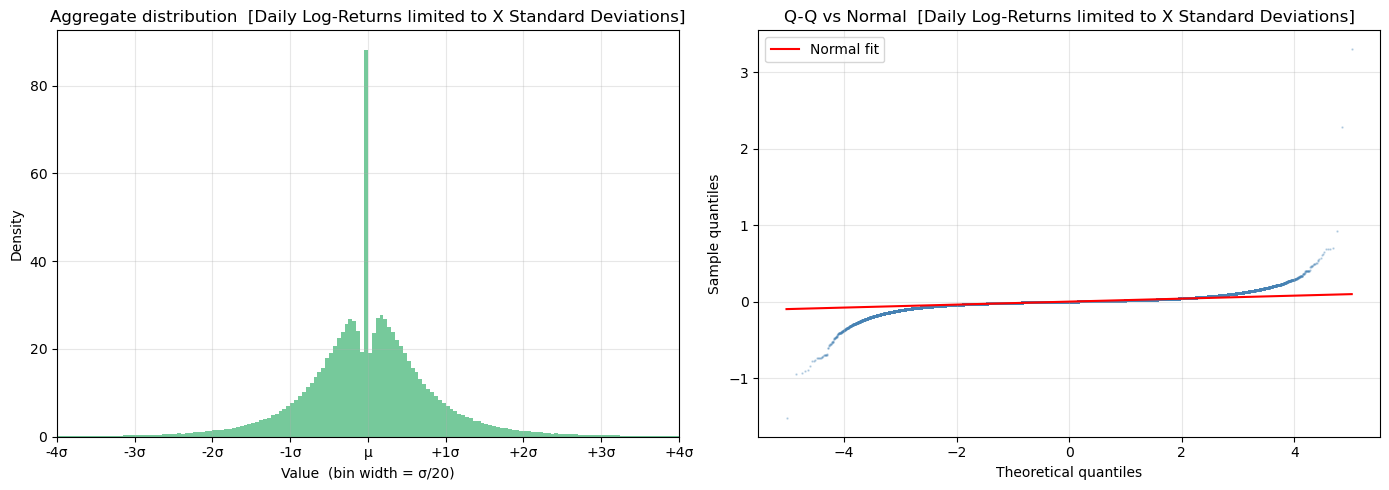

{'count': 2669077,
 'mean': 0.000453121429019384,
 'std': 0.021150695772512995,
 'min': -1.5255260079566049,
 'q25': -0.00861971766868107,
 'median': 0.0,
 'q75': 0.00947968693228882,
 'max': 3.3081069585961433,
 'skewness': 327.19816482610025}

In [553]:
compute_aggregate_stats_and_plot_std(returns_clean, 'Daily Log-Returns limited to X Standard Deviations', n_stds=4, bins_per_std=20)

## Section: investigating jumps and subsequent identical values

In [554]:
zero_thresh  = 1e-10   # treat |r| below this as exactly zero
jump_thresh  = 0.50    # |log-return| above this flagged as a jump (~22% daily move)

audit = []
for ticker, s in returns_clean.items():
    mask_zero  = s.abs() < zero_thresh
    mask_jumps = s.abs() > jump_thresh
    n_zero     = mask_zero.sum()
    n_jumps    = mask_jumps.sum()
    audit.append({
        'ticker':     ticker,
        'n_obs':      len(s),
        'n_zero':     n_zero,
        'n_jumps':    n_jumps,
        'pct_zero':   n_zero  / len(s),
        'pct_jumps':  n_jumps / len(s),
        'mean_zero':  s[mask_zero].mean()  if n_zero  > 0 else np.nan,
        'mean_jump':  s[mask_jumps].mean() if n_jumps > 0 else np.nan,
    })

audit_df = pd.DataFrame(audit).set_index('ticker')

print("── Tickers with most jumps ──")
print(audit_df[audit_df['n_jumps'] > 0].sort_values('n_jumps', ascending=False).head(20).to_string())
print("\n── Tickers with most zero returns ──")
print(audit_df.sort_values('pct_zero', ascending=False).head(20).to_string())


── Tickers with most jumps ──
        n_obs  n_zero  n_jumps  pct_zero  pct_jumps  mean_zero  mean_jump
ticker                                                                   
MNST    10161    2167        8  0.213266   0.000787        0.0   0.147684
TSN     11610    1333        3  0.114815   0.000258        0.0  -0.716685
PCG     13576    1600        3  0.117855   0.000221        0.0  -0.245529
AIG     13430     817        3  0.060834   0.000223        0.0  -0.344452
GL      11472     665        3  0.057967   0.000262        0.0  -0.724158
VTRS    11610     880        3  0.075797   0.000258        0.0  -0.736307
WMB     11157     569        3  0.050999   0.000269        0.0  -0.256266
NVR     10258    1122        3  0.109378   0.000292        0.0   0.423918
COO     10889    1095        2  0.100560   0.000184        0.0   0.524909
MCD     15040     628        2  0.041755   0.000133        0.0  -0.701353
BEN     10719     557        2  0.051964   0.000187        0.0   0.005130
TYL     

In [555]:
def inspect_ticker(ticker, jump_thresh=0.20):
    r = returns_clean[ticker]
    p = raw_clean[ticker]
    jumps = r[r.abs() > jump_thresh]
    print(f"\n── {ticker}: {len(jumps)} jumps (|r| > {jump_thresh}) ──")
    for date in jumps.index:
        window = p.loc[date - pd.Timedelta(days=5) : date + pd.Timedelta(days=5)]
        print(f"\n  Return: {jumps[date]:.4f}  |  Raw prices around {date.date()}:")
        print(window.to_string())

inspect_ticker('NVR')


── NVR: 48 jumps (|r| > 0.2) ──

  Return: -1.5255  |  Raw prices around 1987-06-23:
date
1987-06-18    36.390778
1987-06-19    36.390778
1987-06-22    36.294506
1987-06-23     7.894295
1987-06-24     7.894295
1987-06-25     7.701752
1987-06-26     7.701752

  Return: -0.2451  |  Raw prices around 1987-10-19:
date
1987-10-14    4.780311
1987-10-15    4.682753
1987-10-16    4.487638
1987-10-19    3.512064
1987-10-20    3.414507
1987-10-21    4.097409
1987-10-22    3.804738
1987-10-23    3.414507

  Return: -0.2877  |  Raw prices around 1990-07-17:
date
1990-07-12    1.875
1990-07-13    2.000
1990-07-16    2.000
1990-07-17    1.500
1990-07-18    1.125
1990-07-19    1.500
1990-07-20    1.625

  Return: -0.2877  |  Raw prices around 1990-07-18:
date
1990-07-13    2.000
1990-07-16    2.000
1990-07-17    1.500
1990-07-18    1.125
1990-07-19    1.500
1990-07-20    1.625
1990-07-23    1.750

  Return: 0.2877  |  Raw prices around 1990-07-19:
date
1990-07-16    2.000
1990-07-17    1.500
1990-0

---
## Section 4 — Individually Z-Score Normalised Returns

Each ticker's return series is normalised using its own mean and std:  
`z_t = (r_t − μ) / σ`

In [556]:
# 4.1  Normalise each ticker individually
norm_data = normalize_individually(returns_clean)

Z-score normalised 214 tickers individually.


In [557]:
# 4.2  NaN audit
norm_clean = analyze_nans(norm_data)

No NaN values found in any ticker.
Total NaNs across all tickers: 0


In [558]:
# 4.3  Per-ticker statistics
norm_stats = compute_all_stats(norm_clean)
print(f'Statistics computed for {len(norm_stats)} tickers.')
norm_stats.head()

Statistics computed for 214 tickers.


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
AAPL,11422.0,7.153950e-18,1.0,-26.149062,-0.470718,-0.024654,0.477023,10.224785,-1.731976,48.170627
ABT,11610.0,-1.836028e-18,1.0,-11.035684,-0.534409,-0.034047,0.533377,7.310136,-0.269159,5.618790
ADI,11610.0,1.040416e-17,1.0,-7.916998,-0.492235,-0.021116,0.469060,6.960436,0.076587,5.223629
ADM,11610.0,1.193418e-17,1.0,-14.200041,-0.498030,-0.019282,0.520965,8.164992,-0.489668,10.784514
ADP,11610.0,1.285219e-17,1.0,-17.009420,-0.478359,-0.032437,0.494566,9.953782,-0.798189,18.852504


In [559]:
# 4.4  Distribution of statistics
describe_stats(norm_stats, 'Normalised Returns')


Distribution of per-ticker statistics  [Normalised Returns]
              count   mean    std         min         q25      median         q75         max    skewness     kurtosis
count    214.000000  214.0  214.0  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   214.000000
mean   12472.322430    0.0    1.0  -15.537127   -0.464159   -0.023094    0.464140   11.830185   -0.161779    66.061340
std     1698.796946    0.0    0.0    6.946454    0.057590    0.007262    0.057233    8.116106    4.881536   430.675809
min    10083.000000   -0.0    1.0  -42.978004   -0.545263   -0.042849    0.096331    5.583797  -10.238005     3.741907
25%    11468.250000   -0.0    1.0  -17.307867   -0.500347   -0.027874    0.444355    8.559019   -0.585283     8.518035
50%    11610.000000    0.0    1.0  -13.509520   -0.478772   -0.023691    0.474651   10.220735   -0.268473    13.324422
75%    13396.000000    0.0    1.0  -10.985247   -0.447119   -0.018706    0.498823   12.318487   -0.023632 

In [560]:
# # 4.5  Histograms of statistics
# plot_stat_histograms(norm_stats, 'Normalised Returns')

In [561]:
# 4.6  Quantile filter
quantile_level = 0.9  # ← SET

norm_outliers = quantile_filter(norm_stats, quantile_level)


90%-quantile thresholds per statistic:
count       16175.000000
mean            0.000000
std             1.000000
min            -9.036964
q25            -0.397714
median         -0.013396
q75             0.514800
max            15.856037
skewness        0.153081
kurtosis       59.690458

Tickers exceeding at least one 90% threshold: 112
          count  mean  std      min     q25  median     q75      max  skewness   kurtosis
ticker                                                                                   
ABT     11610.0  -0.0  1.0 -11.0357 -0.5344 -0.0340  0.5334   7.3101   -0.2692     5.6188
ADI     11610.0   0.0  1.0  -7.9170 -0.4922 -0.0211  0.4691   6.9604    0.0766     5.2236
ADM     11610.0   0.0  1.0 -14.2000 -0.4980 -0.0193  0.5210   8.1650   -0.4897    10.7845
ADP     11610.0   0.0  1.0 -17.0094 -0.4784 -0.0324  0.4946   9.9538   -0.7982    18.8525
ADSK    10273.0   0.0  1.0  -9.0129 -0.4893 -0.0212  0.4860  11.8872   -0.2874     8.4536
AFL     11610.0  -0.0  1.0 -2

Tickers not found: ['AMZN']

── AAPL  [Normalised Returns] ──
count       11422.000000
mean            0.000000
std             1.000000
min           -26.149062
25%            -0.470718
50%            -0.024654
75%             0.477023
max            10.224785
skewness       -1.731976
kurtosis       48.170627


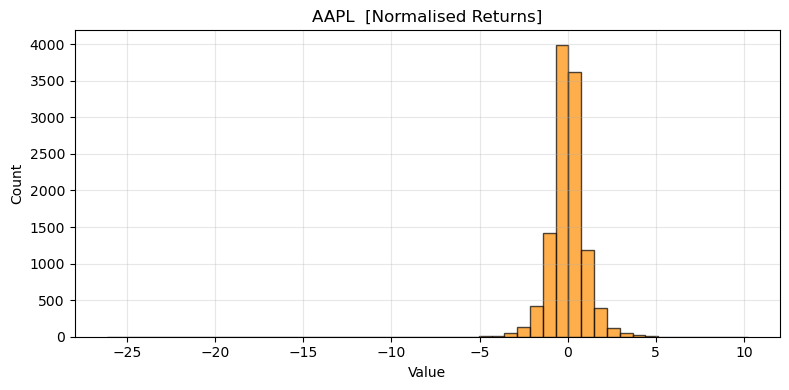


── MSFT  [Normalised Returns] ──
count       10096.000000
mean            0.000000
std             1.000000
min           -17.134943
25%            -0.474443
50%            -0.023461
75%             0.482465
max             8.482892
skewness       -0.564158
kurtosis       14.944640


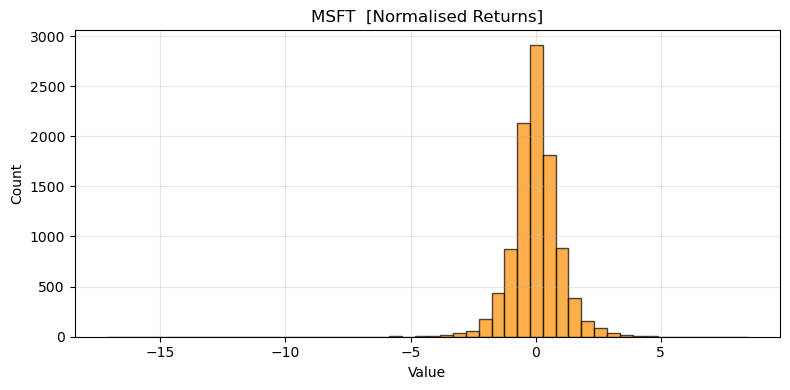

In [562]:
# 4.7  Ticker histograms
tickers_to_plot = ['AAPL', 'MSFT', 'AMZN']  # ← SET

plot_ticker_histograms(norm_clean, tickers_to_plot, 'Normalised Returns')


Aggregate statistics  [Normalised Returns]  (N=2,669,077)
  count       : 2,669,077
  mean        : 3.35428e-19
  std         : 0.99996
  min         : -42.978
  q25         : -0.464465
  median      : -0.0211267
  q75         : 0.46457
  max         : 94.957
  skewness    : -0.166597
  kurtosis    : 66.9529


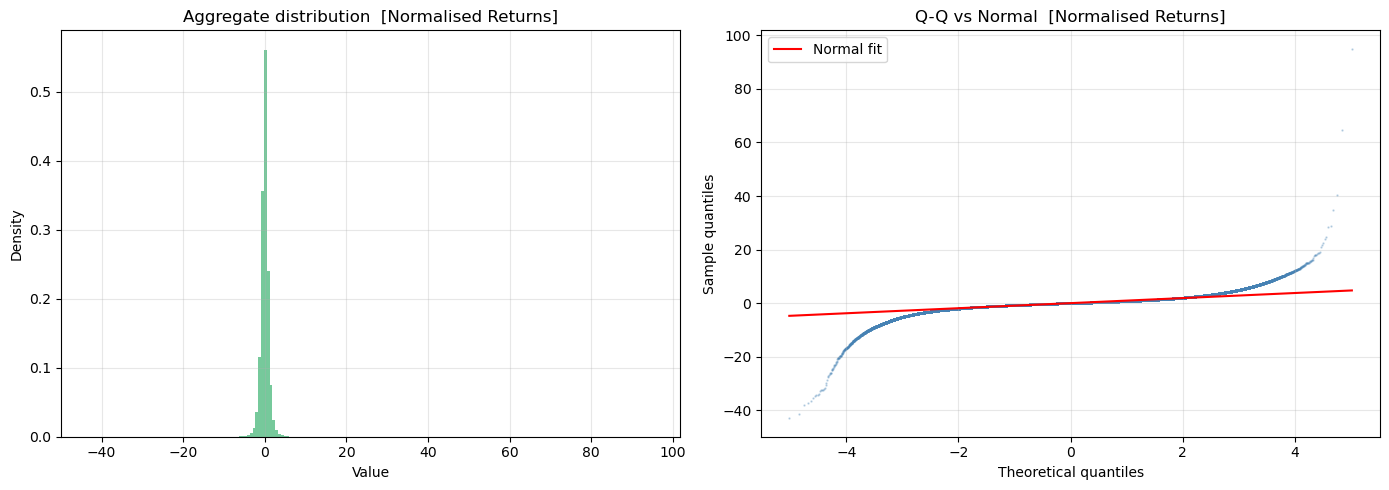

In [563]:
# 4.8  Aggregate statistics + distribution
norm_agg = compute_aggregate_stats_and_plot(norm_clean, 'Normalised Returns')


Aggregate statistics  [Normalised Returns]  (N=2,669,077)
  count       : 2,669,077
  mean        : 3.35428e-19
  std         : 0.99996
  min         : -42.978
  q25         : -0.464465
  median      : -0.0211267
  q75         : 0.46457
  max         : 94.957
  skewness    : 66.9529


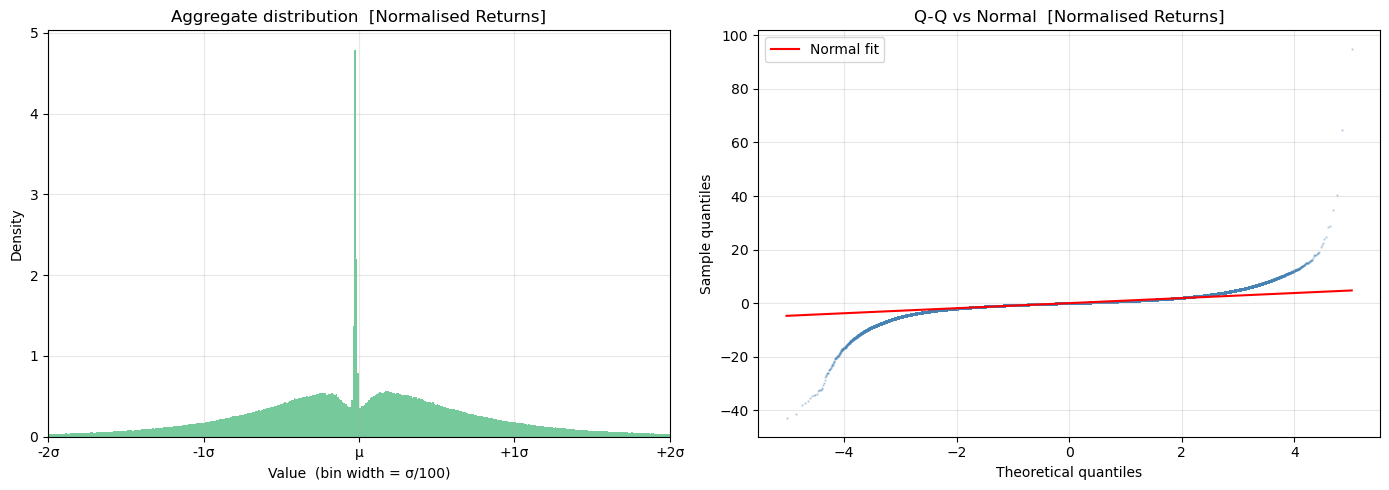

In [564]:
# 4.8  Aggregate statistics + distribution
norm_agg = compute_aggregate_stats_and_plot_std(norm_clean, 'Normalised Returns')

---
## Section 5 — Rolling Window Z-Score Normalised Returns

At each time step `t`, normalise using a rolling window of size `window_size`:  
`z_t = (r_t − μ_{t-w:t}) / σ_{t-w:t}`

Set `window_size` in the cell below.

In [565]:
# ← SET window size here
window_size = 64  # e.g. 252 trading days ≈ 1 year

In [566]:
# 5.1  Rolling window normalisation
wnorm_data = window_normalize(log_clean, window_size)

Window-wise normalisation (window=64): dropped 16606 leading obs total.


In [567]:
# 5.2  NaN audit (leading window_size-1 rows already dropped)
wnorm_clean = analyze_nans(wnorm_data)

No NaN values found in any ticker.
Total NaNs across all tickers: 0


In [568]:
# 5.3  Per-ticker statistics
wnorm_stats = compute_all_stats(wnorm_clean)
print(f'Statistics computed for {len(wnorm_stats)} tickers.')
wnorm_stats.head()

Statistics computed for 214 tickers.


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
AAPL,11360.0,0.342405,1.374599,-5.723644,-0.744479,0.582134,1.438525,4.470865,-0.393957,-0.569871
ABT,11548.0,0.421417,1.307414,-5.742094,-0.539885,0.656892,1.414923,4.481070,-0.492618,-0.274612
ADI,11548.0,0.258763,1.328017,-4.793672,-0.725809,0.413285,1.304818,5.843974,-0.314963,-0.491557
ADM,11548.0,0.220967,1.375706,-6.687946,-0.854829,0.375848,1.317136,4.189882,-0.278231,-0.588723
ADP,11548.0,0.406474,1.306784,-5.607846,-0.520072,0.593301,1.402152,4.458408,-0.467386,-0.176948


In [569]:
# 5.4  Distribution of statistics
describe_stats(wnorm_stats, f'Window-Norm Returns (w={window_size})')


Distribution of per-ticker statistics  [Window-Norm Returns (w=64)]
              count        mean         std         min         q25      median         q75         max    skewness    kurtosis
count    214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000
mean   12395.724299    0.306311    1.352568   -5.608577   -0.709802    0.502745    1.352762    4.902064   -0.364956   -0.392361
std     1703.390996    0.081846    0.025052    0.728648    0.130223    0.113192    0.055893    0.780266    0.089670    0.252613
min    10021.000000    0.048971    1.290901   -7.875000   -1.079464    0.112570    1.172896    3.775317   -0.579064   -0.779597
25%    11391.500000    0.252147    1.334976   -6.019799   -0.799550    0.438967    1.316197    4.440998   -0.426238   -0.513627
50%    11548.000000    0.308987    1.351350   -5.516363   -0.702444    0.515910    1.356600    4.727653   -0.367039   -0.403998
75%    13334.000000    0.358551    

In [571]:
# 5.6  Quantile filter
quantile_level = 0.9  # ← SET

wnorm_outliers = quantile_filter(wnorm_stats, quantile_level)


90%-quantile thresholds per statistic:
count       16113.000000
mean            0.406697
std             1.385192
min            -4.783653
q25            -0.550648
median          0.631406
q75             1.418377
max             5.852309
skewness       -0.260532
kurtosis       -0.180918

Tickers exceeding at least one 90% threshold: 98
          count    mean     std     min     q25  median     q75     max  skewness  kurtosis
ticker                                                                                     
AAPL    11360.0  0.3424  1.3746 -5.7236 -0.7445  0.5821  1.4385  4.4709   -0.3940   -0.5699
ABT     11548.0  0.4214  1.3074 -5.7421 -0.5399  0.6569  1.4149  4.4811   -0.4926   -0.2746
ADP     11548.0  0.4065  1.3068 -5.6078 -0.5201  0.5933  1.4022  4.4584   -0.4674   -0.1769
AEP     16113.0  0.2949  1.3432 -4.7238 -0.7075  0.4563  1.3381  4.1420   -0.3048   -0.4959
AFL     11548.0  0.4130  1.3341 -5.0902 -0.5247  0.6493  1.3975  5.9292   -0.4821   -0.1113
AMD     11548.0 

Tickers not found: ['AMZN']

── AAPL  [Window-Norm (w=64)] ──
count       11360.000000
mean            0.342405
std             1.374599
min            -5.723644
25%            -0.744479
50%             0.582134
75%             1.438525
max             4.470865
skewness       -0.393957
kurtosis       -0.569871


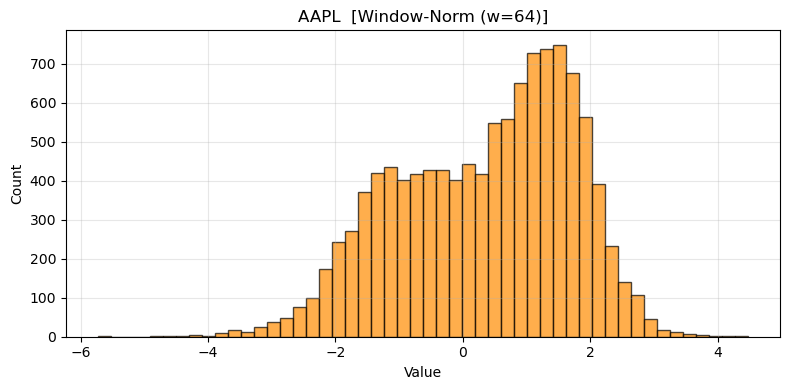


── MSFT  [Window-Norm (w=64)] ──
count       10034.000000
mean            0.438968
std             1.330012
min            -5.752213
25%            -0.558319
50%             0.668718
75%             1.454259
max             4.738764
skewness       -0.424266
kurtosis       -0.393368


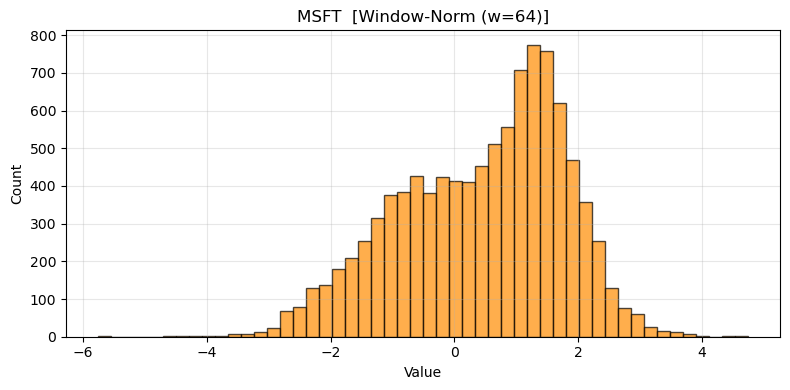

In [572]:
# 5.7  Ticker histograms
tickers_to_plot = ['AAPL', 'MSFT', 'AMZN']  # ← SET

plot_ticker_histograms(wnorm_clean, tickers_to_plot, f'Window-Norm (w={window_size})')


Aggregate statistics  [Window-Norm Returns (w=64)]  (N=2,652,685)
  count       : 2,652,685
  mean        : 0.305431
  std         : 1.35494
  min         : -7.875
  q25         : -0.716946
  median      : 0.505936
  q75         : 1.35594
  max         : 7.875
  skewness    : -0.36378
  kurtosis    : -0.407433


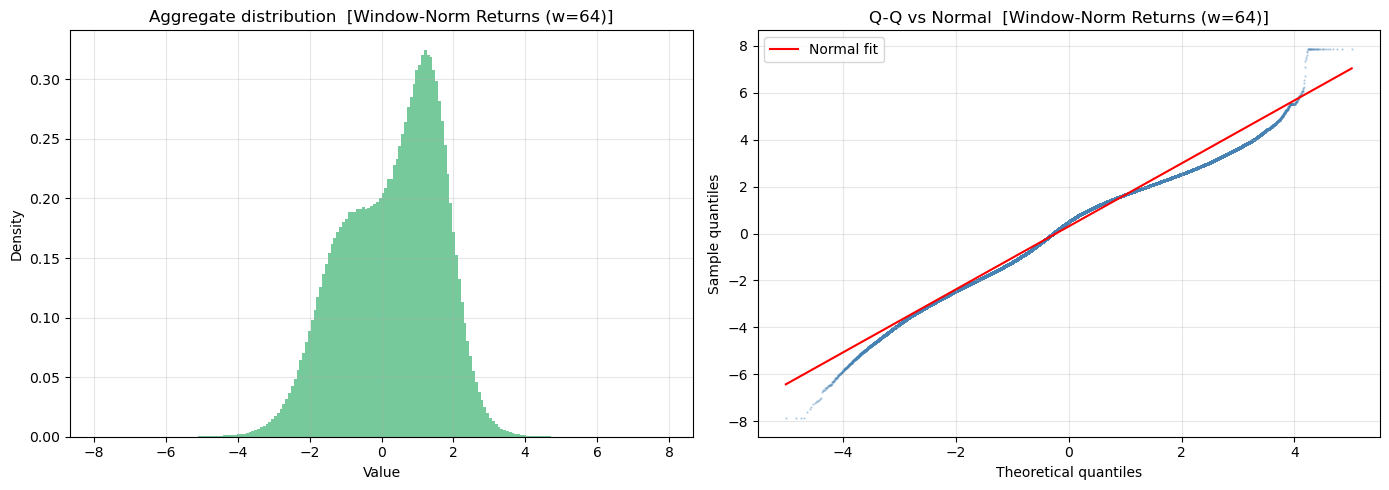

In [573]:
# 5.8  Aggregate statistics + distribution
wnorm_agg = compute_aggregate_stats_and_plot(wnorm_clean, f'Window-Norm Returns (w={window_size})')